# Milestone 3 — Classification of Electoral Volatility

**Author:** Antoni Czolgowski  
**Course:** CSCI 5502 Data Mining — Spring 2026  
**Date:** March 2026

---

This notebook predicts county-level electoral volatility from demographic features using four supervised classification approaches:

- **Model A** — Random Forest
- **Model B** — XGBoost (Gradient Boosted Trees)
- **Model C** — SVM (Support Vector Machine)
- **Model D** — Demographic Misfit Detector (Logistic Regression residual analysis)

Plus a **cross-state generalization experiment** and **choropleth visualizations**.

**Unit of analysis:** 250 counties across PA, MI, NC (2024 demographic snapshot).  
**Target:** `vol_z_abs_sum` binned into 5 quintile classes.

In [1]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, GridSearchCV,
    cross_val_predict, cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import shap

import geopandas as gpd
import json
from urllib.request import urlopen

from scipy.stats import pearsonr, spearmanr

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

BASE = '../data/processed'
FIG_DIR = '../docs/images/methods'
os.makedirs(FIG_DIR, exist_ok=True)

print('All imports loaded successfully.')

All imports loaded successfully.


---
## 1. Data Preparation Pipeline

### Step 1 — Load Source Files

In [3]:
master_raw = pd.read_csv(f'{BASE}/master_dataset.csv', dtype={'county_fips': str})
master_scaled = pd.read_csv(f'{BASE}/master_dataset_scaled.csv', dtype={'county_fips': str})
volatility = pd.read_csv(f'{BASE}/county_volatility_dimTable.csv', dtype={'county_fips': str})

master_raw['county_fips'] = master_raw['county_fips'].str.zfill(5)
master_scaled['county_fips'] = master_scaled['county_fips'].str.zfill(5)
volatility['county_fips'] = volatility['county_fips'].str.zfill(5)

print(f'master_raw:    {master_raw.shape}')
print(f'master_scaled: {master_scaled.shape}')
print(f'volatility:    {volatility.shape}')

master_raw:    (750, 39)
master_scaled: (750, 40)
volatility:    (250, 14)


### Step 2 — Filter to 2024, Merge Volatility Target & race_entropy_norm

In [5]:
df = master_raw[master_raw['election_year'] == 2024].copy().reset_index(drop=True)
print(f'2024 subset: {df.shape}')

entropy_2024 = master_scaled[master_scaled['election_year'] == 2024][['county_fips', 'race_entropy_norm']].copy()

df = df.merge(volatility[['county_fips', 'vol_z_abs_sum', 'swing_dir_score', 'vol_z_euc']],
              on='county_fips', how='left')

df = df.merge(entropy_2024, on='county_fips', how='left')

assert df.shape[0] == 250, f'Expected 250 rows, got {df.shape[0]}'
assert df['vol_z_abs_sum'].notna().all(), 'Null values in target!'
assert df['race_entropy_norm'].notna().all(), 'Null values in race_entropy_norm!'
print(f'Merged dataset: {df.shape}')
print(f'Nulls in target: {df["vol_z_abs_sum"].isna().sum()}')
print(f'Nulls in race_entropy_norm: {df["race_entropy_norm"].isna().sum()}')

2024 subset: (250, 39)
Merged dataset: (250, 43)
Nulls in target: 0
Nulls in race_entropy_norm: 0


### Step 3 — Create Target Variables (5-class, numeric, binary)

In [6]:
df['volatility_class'] = pd.qcut(
    df['vol_z_abs_sum'], q=5,
    labels=['Very Stable', 'Stable', 'Moderate', 'Volatile', 'Highly Volatile']
)

df['vol_quintile_num'] = pd.qcut(df['vol_z_abs_sum'], q=5, labels=False) + 1

df['vol_binary'] = (df['vol_quintile_num'] >= 4).astype(int)

bin_edges = pd.qcut(df['vol_z_abs_sum'], q=5, retbins=True)[1]
print('Quintile bin edges:', np.round(bin_edges, 4))
print('\nClass distribution:')
print(df['volatility_class'].value_counts().sort_index())
print(f'\nBinary split — High (Q4+Q5): {df["vol_binary"].sum()}, Low (Q1-Q3): {(1-df["vol_binary"]).sum()}')

Quintile bin edges: [-2.4096 -1.3148 -0.607   0.0441  1.1902  8.0285]

Class distribution:
volatility_class
Very Stable        50
Stable             50
Moderate           50
Volatile           50
Highly Volatile    50
Name: count, dtype: int64

Binary split — High (Q4+Q5): 100, Low (Q1-Q3): 150


### Step 4 — Feature Selection (Demographics Only)

In [7]:
exclude_cols = [
    'county_fips', 'state', 'county_name', 'election_year',
    'dem_votes', 'rep_votes', 'total_votes', 'dem_pct', 'rep_pct', 'dem_margin',
    'vol_z_abs_sum', 'vol_z_euc', 'swing_dir_score',
    'volatility_class', 'vol_quintile_num', 'vol_binary'
]

state_series = df['state'].copy()
dem_margin_series = df['dem_margin'].copy()
county_fips_series = df['county_fips'].copy()
county_name_series = df['county_name'].copy()

feature_cols = [c for c in df.columns if c not in exclude_cols]
df_features = df[feature_cols].copy()

print(f'Feature count before transforms: {len(feature_cols)}')
print(f'Features: {feature_cols}')

Feature count before transforms: 30
Features: ['total_population', 'median_age', 'pct_black', 'pct_asian', 'pct_two_or_more_races', 'pct_hispanic', 'pct_non_hispanic_white', 'pct_hs_or_higher', 'pct_bachelors_plus', 'pct_below_poverty', 'median_household_income', 'pct_income_under_25k', 'pct_income_50k_100k', 'pct_income_over_100k', 'unemployment_rate', 'pct_owner_occupied', 'median_gross_rent', 'median_home_value', 'pct_drive_alone', 'pct_carpool', 'pct_public_transit', 'pct_work_from_home', 'pct_family_households', 'pct_married_couple', 'pct_living_alone', 'population_density', 'pct_senior_65plus', 'pct_young_adult_18_24', 'pct_foreign_born', 'race_entropy_norm']


### Step 5 — Log-Transform 5 Skewed Variables

Applying `np.log1p()` to reduce skewness in heavy-tailed variables (consistent with M2 pipeline).

In [8]:
desc_raw = df_features.describe().T[['mean', 'std', 'min', 'max']]
desc_raw['skew'] = df_features.skew()

log_cols = ['total_population', 'population_density',
            'median_household_income', 'median_home_value', 'median_gross_rent']

print('Skewness before/after log-transform:')
print(f'{"Variable":<30} {"Before":>8} {"After":>8}')
print('-' * 48)

for col in log_cols:
    skew_before = df_features[col].skew()
    df_features[f'log_{col}'] = np.log1p(df_features[col])
    skew_after = df_features[f'log_{col}'].skew()
    print(f'{col:<30} {skew_before:>8.2f} {skew_after:>8.2f}')

df_features.drop(columns=log_cols, inplace=True)

feature_names = list(df_features.columns)
print(f'\nFeature count after log-transform: {len(feature_names)}')

Skewness before/after log-transform:
Variable                         Before    After
------------------------------------------------
total_population                   4.06     0.26
population_density                10.98     0.35
median_household_income            1.15     0.45
median_home_value                  1.14     0.28
median_gross_rent                  1.08     0.57

Feature count after log-transform: 30


### Step 6 — Multicollinearity Check & Feature Drops

In [9]:
corr = df_features.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = []
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.85:
            high_corr.append((row, col, upper.loc[row, col]))

high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)
print('Highly correlated pairs (|r| > 0.85):')
print(high_corr_df.to_string(index=False))

drop_features = ['pct_income_over_100k']
print(f'\nDefinite drop: pct_income_over_100k (redundant with log_median_household_income)')

if 'pct_non_hispanic_white' in df_features.columns and 'race_entropy_norm' in df_features.columns:
    r_val, p_val = pearsonr(df_features['pct_non_hispanic_white'], df_features['race_entropy_norm'])
    print(f'\npct_non_hispanic_white vs race_entropy_norm: r={r_val:.3f}, p={p_val:.4f}')
    if abs(r_val) > 0.85:
        drop_features.append('pct_non_hispanic_white')
        print('Dropping pct_non_hispanic_white (redundant with race_entropy_norm)')
    else:
        print('Keeping pct_non_hispanic_white (correlation below threshold)')

df_features.drop(columns=drop_features, inplace=True)

X_unscaled = df_features.copy()

feature_names = list(df_features.columns)
print(f'\nFinal feature count: {len(feature_names)}')
print(f'Features: {feature_names}')

Highly correlated pairs (|r| > 0.85):
             Feature 1                   Feature 2  Correlation
  pct_income_over_100k log_median_household_income     0.963573
            median_age           pct_senior_65plus     0.948056
  log_total_population      log_population_density     0.939887
pct_non_hispanic_white           race_entropy_norm     0.930021
             pct_black      pct_non_hispanic_white     0.921417
  pct_income_under_25k log_median_household_income     0.912602
     pct_below_poverty        pct_income_under_25k     0.884098
 pct_family_households            pct_living_alone     0.878939

Definite drop: pct_income_over_100k (redundant with log_median_household_income)

pct_non_hispanic_white vs race_entropy_norm: r=-0.930, p=0.0000
Dropping pct_non_hispanic_white (redundant with race_entropy_norm)

Final feature count: 28
Features: ['median_age', 'pct_black', 'pct_asian', 'pct_two_or_more_races', 'pct_hispanic', 'pct_hs_or_higher', 'pct_bachelors_plus', 'pct_below_po

### Step 7 — StandardScale + Before/After Snapshots

In [10]:
desc_log = df_features.describe().T[['mean', 'std', 'min', 'max']]
desc_log['skew'] = df_features.skew()

scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(df_features)
X = pd.DataFrame(X_scaled_arr, columns=feature_names, index=df_features.index)

desc_scaled = X.describe().T[['mean', 'std', 'min', 'max']]

print('=== BEFORE TRANSFORMS (Raw 2024) ===')
print(desc_raw.round(3).head(10))
print('\n=== AFTER LOG-TRANSFORM (Pre-scaling) ===')
print(desc_log.round(3).head(10))
print('\n=== AFTER STANDARD SCALING ===')
print(desc_scaled.round(3).head(10))
print(f'\nScaled matrix shape: {X.shape}')
print(f'Mean ~ 0: {X.mean().mean():.6f}, Std ~ 1: {X.std().mean():.4f}')

=== BEFORE TRANSFORMS (Raw 2024) ===
                              mean         std       min          max   skew
total_population        135307.216  239930.973  2133.000  1772259.000  4.057
median_age                  44.096       5.439    27.700       60.000  0.254
pct_black                   10.097      13.193     0.000       59.627  1.724
pct_asian                    1.334       1.747     0.000        9.234  2.566
pct_two_or_more_races        6.304       2.395     2.287       15.287  1.113
pct_hispanic                 6.338       4.842     0.700       27.977  1.461
pct_non_hispanic_white      77.335      16.643    23.252       95.456 -1.093
pct_hs_or_higher            90.476       3.525    79.000       97.118 -0.740
pct_bachelors_plus          25.895       9.905     9.909       61.757  1.249
pct_below_poverty           13.599       4.143     5.076       27.229  0.700

=== AFTER LOG-TRANSFORM (Pre-scaling) ===
                         mean     std     min     max   skew
median_age  

### Step 8 — Save Intermediate Files & Define Target Arrays

In [11]:
save_df = pd.DataFrame({
    'county_fips': county_fips_series.values,
    'state': state_series.values,
    'county_name': county_name_series.values
})
save_df = pd.concat([save_df, X.reset_index(drop=True)], axis=1)
save_df['volatility_class'] = df['volatility_class'].values
save_df['vol_quintile_num'] = df['vol_quintile_num'].values
save_df['vol_binary'] = df['vol_binary'].values
save_df['vol_z_abs_sum'] = df['vol_z_abs_sum'].values

save_df.to_csv(f'{BASE}/classification_dataset_250.csv', index=False)
print(f'Saved: {BASE}/classification_dataset_250.csv ({save_df.shape})')

y = df['vol_quintile_num'].values
y_labels = df['volatility_class'].values
y_binary = df['vol_binary'].values

CLASS_NAMES = ['Q1_VeryStable', 'Q2_Stable', 'Q3_Moderate', 'Q4_Volatile', 'Q5_HighlyVolatile']

print(f'\ny shape: {y.shape}, classes: {np.unique(y)}')
print(f'y_binary distribution: {np.bincount(y_binary)[1:]}  (Low/High)')

Saved: ../data/processed/classification_dataset_250.csv ((250, 35))

y shape: (250,), classes: [1 2 3 4 5]
y_binary distribution: [100]  (Low/High)


---
## 2. Helper Functions

Reusable nested CV and evaluation utilities for Models A–C.

In [12]:
def nested_cv(X, y, base_model, param_grid, n_iter=80, model_name='Model'):
    """Run nested stratified CV: outer 5-fold evaluation, inner 3-fold tuning.
    Returns predictions for all samples plus fold-level metrics."""
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    n_classes = len(np.unique(y))
    all_preds = np.zeros(len(y), dtype=int)
    all_proba = np.zeros((len(y), n_classes))
    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        X_train = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        X_test = X.iloc[test_idx] if hasattr(X, 'iloc') else X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grid,
            n_iter=min(n_iter, np.prod([len(v) if isinstance(v, list) else 1 for v in param_grid.values()])),
            cv=inner_cv,
            scoring='f1_macro',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            error_score='raise'
        )
        search.fit(X_train, y_train)

        preds = search.best_estimator_.predict(X_test)
        proba = search.best_estimator_.predict_proba(X_test)

        all_preds[test_idx] = preds
        all_proba[test_idx] = proba

        fold_f1 = f1_score(y_test, preds, average='macro')
        fold_acc = accuracy_score(y_test, preds)
        fold_metrics.append({
            'fold': fold_idx,
            'accuracy': fold_acc,
            'f1_macro': fold_f1,
            'best_params': search.best_params_
        })
        print(f'  Fold {fold_idx+1}: acc={fold_acc:.3f}, F1-macro={fold_f1:.3f}')

    return all_preds, all_proba, fold_metrics


def evaluate_model(y_true, y_pred, y_proba, y_binary, class_names, model_name='Model'):
    """Compute and print all evaluation metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    f1_per_class = f1_score(y_true, y_pred, average=None)

    proba_high = y_proba[:, 3] + y_proba[:, 4] if y_proba.shape[1] == 5 else y_proba[:, 1]
    auc_binary = roc_auc_score(y_binary, proba_high)

    print(f'\n=== {model_name} — Evaluation ===')
    print(f'Accuracy:        {acc:.4f}')
    print(f'Precision (macro): {prec:.4f}')
    print(f'Recall (macro):    {rec:.4f}')
    print(f'F1-macro:          {f1:.4f}')
    print(f'ROC-AUC (binary):  {auc_binary:.4f}')
    print(f'\nPer-class F1: {dict(zip(class_names, np.round(f1_per_class, 4)))}')
    print(f'\n{classification_report(y_true, y_pred, target_names=class_names)}')

    return {'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec,
            'f1_macro': f1, 'roc_auc_binary': auc_binary, 'f1_per_class': f1_per_class}


def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path):
    """Plot and save confusion matrix."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=class_names, cmap='Blues', ax=ax
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

---
## 3. Model A — Random Forest

### 3.1 Hyperparameter Tuning + Nested CV

In [13]:
rf_base = RandomForestClassifier(random_state=RANDOM_STATE)

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

print('Random Forest — Nested CV (5-fold outer, 3-fold inner):')
rf_preds, rf_proba, rf_fold_metrics = nested_cv(
    X, y, rf_base, rf_param_grid, n_iter=80, model_name='Random Forest'
)

print('\nBest params per fold:')
for fm in rf_fold_metrics:
    print(f'  Fold {fm["fold"]+1}: {fm["best_params"]}')

Random Forest — Nested CV (5-fold outer, 3-fold inner):
  Fold 1: acc=0.360, F1-macro=0.367
  Fold 2: acc=0.300, F1-macro=0.302
  Fold 3: acc=0.340, F1-macro=0.315
  Fold 4: acc=0.420, F1-macro=0.385
  Fold 5: acc=0.420, F1-macro=0.411

Best params per fold:
  Fold 1: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 5, 'class_weight': 'balanced'}
  Fold 2: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 5, 'class_weight': 'balanced'}
  Fold 3: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10, 'class_weight': 'balanced'}
  Fold 4: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_depth': 15, 'class_weight': 'balanced'}
  Fold 5: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 5, 'class_weight': 'balanced_subsample'}


### 3.2 Evaluation Metrics

In [14]:
rf_metrics = evaluate_model(y, rf_preds, rf_proba, y_binary, CLASS_NAMES, 'Random Forest')


=== Random Forest — Evaluation ===
Accuracy:        0.3680
Precision (macro): 0.3581
Recall (macro):    0.3680
F1-macro:          0.3619
ROC-AUC (binary):  0.8031

Per-class F1: {'Q1_VeryStable': np.float64(0.4587), 'Q2_Stable': np.float64(0.1778), 'Q3_Moderate': np.float64(0.2574), 'Q4_Volatile': np.float64(0.3469), 'Q5_HighlyVolatile': np.float64(0.5686)}

                   precision    recall  f1-score   support

    Q1_VeryStable       0.42      0.50      0.46        50
        Q2_Stable       0.20      0.16      0.18        50
      Q3_Moderate       0.25      0.26      0.26        50
      Q4_Volatile       0.35      0.34      0.35        50
Q5_HighlyVolatile       0.56      0.58      0.57        50

         accuracy                           0.37       250
        macro avg       0.36      0.37      0.36       250
     weighted avg       0.36      0.37      0.36       250



### 3.3 Confusion Matrix

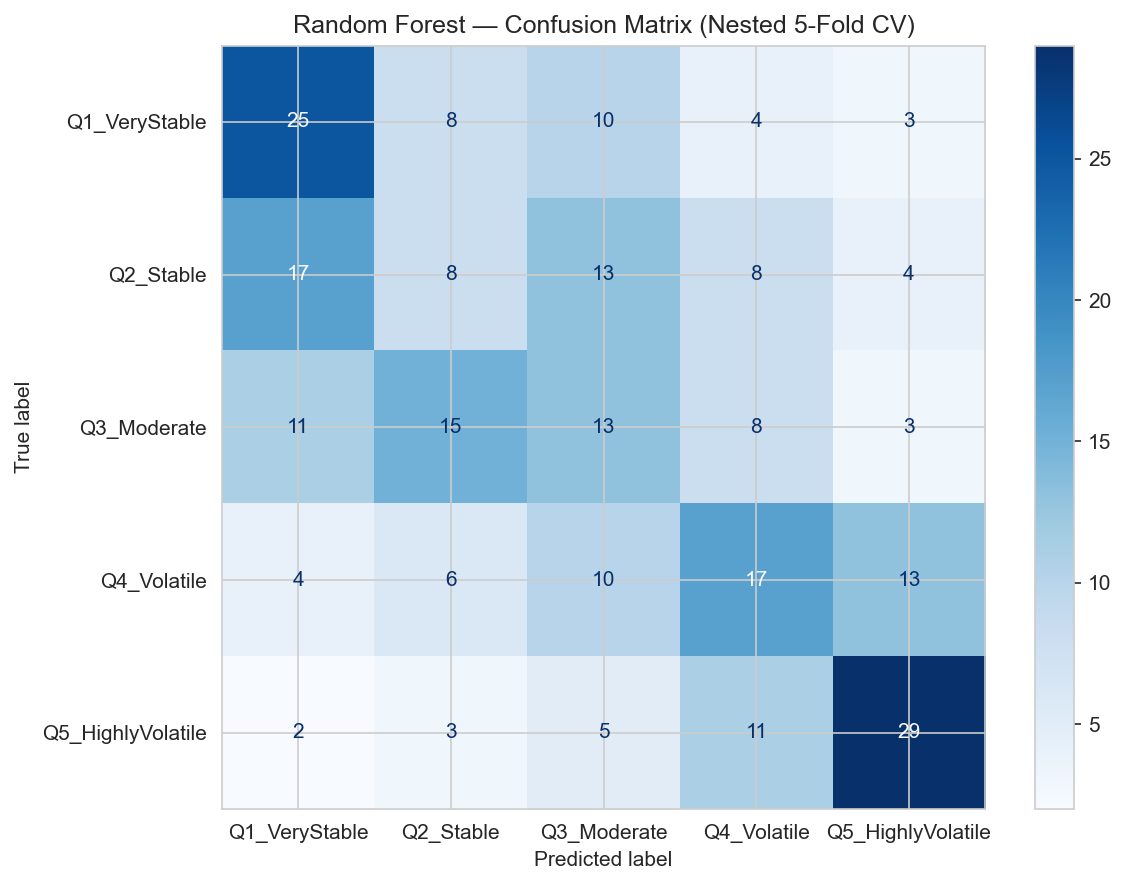

Saved: ../docs/images/methods/rf_confusion_matrix.png


In [15]:
plot_confusion_matrix(
    y, rf_preds, CLASS_NAMES,
    'Random Forest — Confusion Matrix (Nested 5-Fold CV)',
    f'{FIG_DIR}/rf_confusion_matrix.png'
)

### 3.4 Feature Importance — Gini (MDI)

Using params from fold 5 (F1=0.4114)


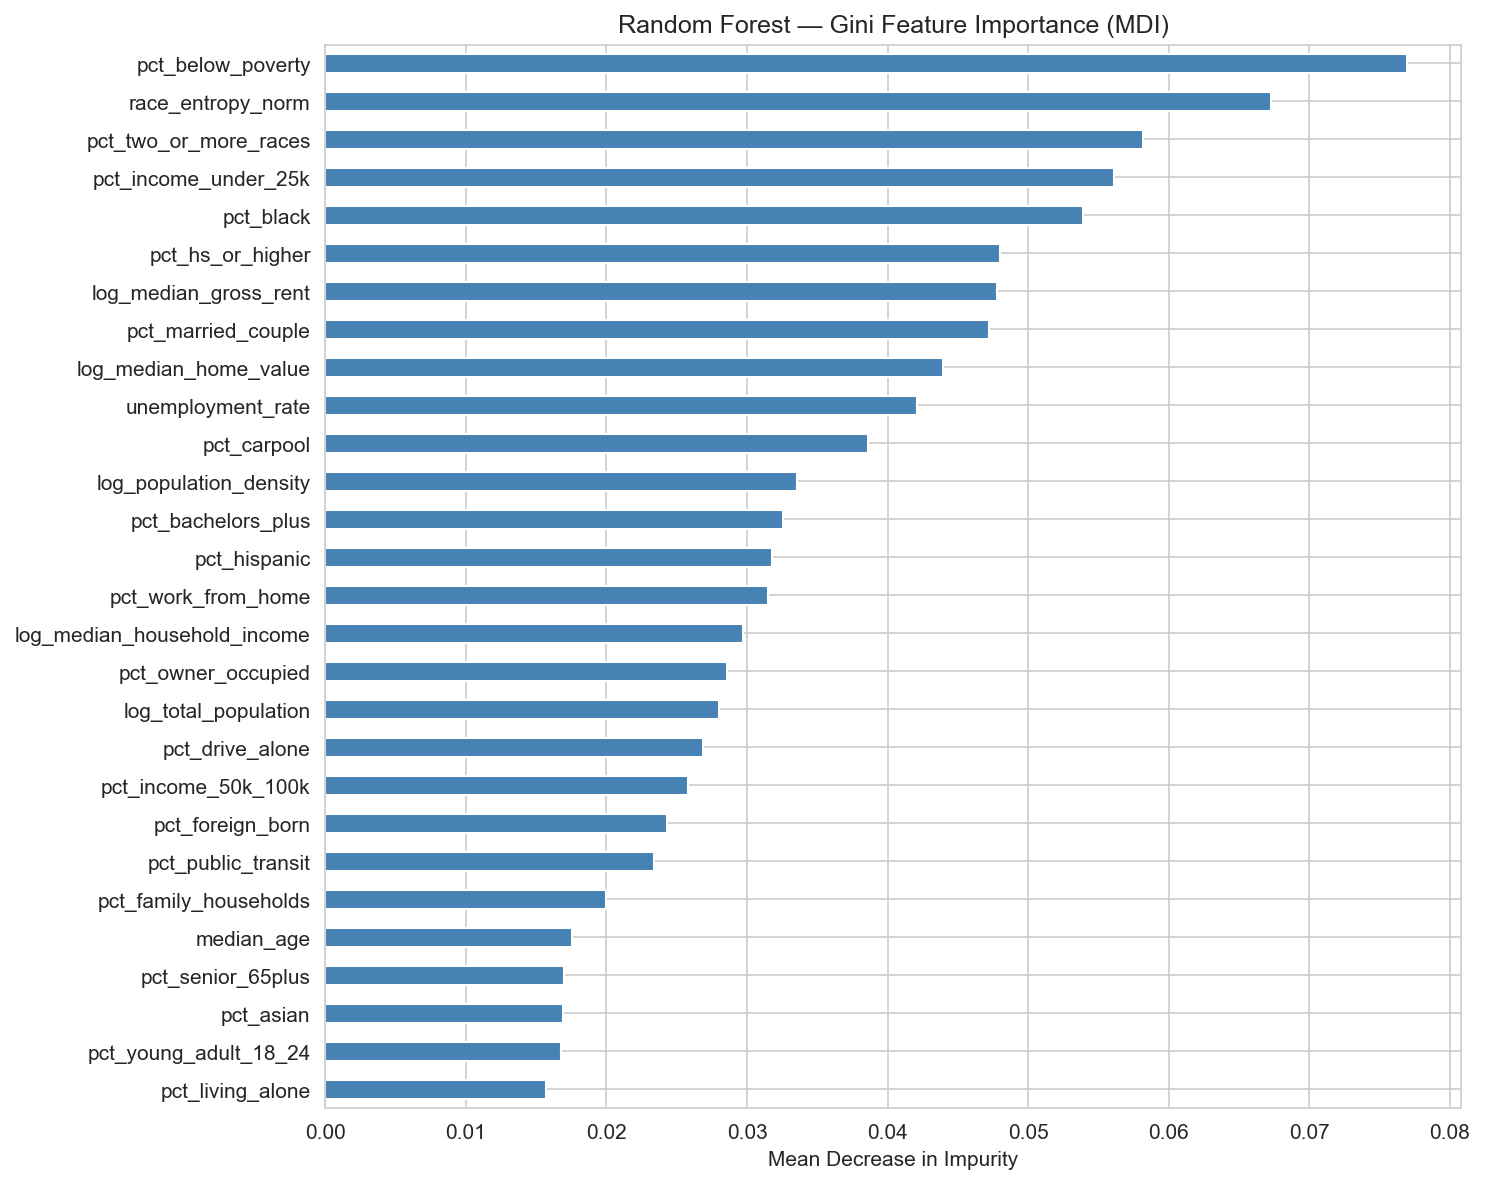

In [16]:
best_fold_idx = max(range(len(rf_fold_metrics)), key=lambda i: rf_fold_metrics[i]['f1_macro'])
rf_best_params = rf_fold_metrics[best_fold_idx]['best_params']
print(f'Using params from fold {best_fold_idx+1} (F1={rf_fold_metrics[best_fold_idx]["f1_macro"]:.4f})')

rf_final = RandomForestClassifier(**rf_best_params, random_state=RANDOM_STATE)
rf_final.fit(X, y)

gini_imp = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
gini_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Gini Feature Importance (MDI)')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_gini_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Feature Importance — Permutation

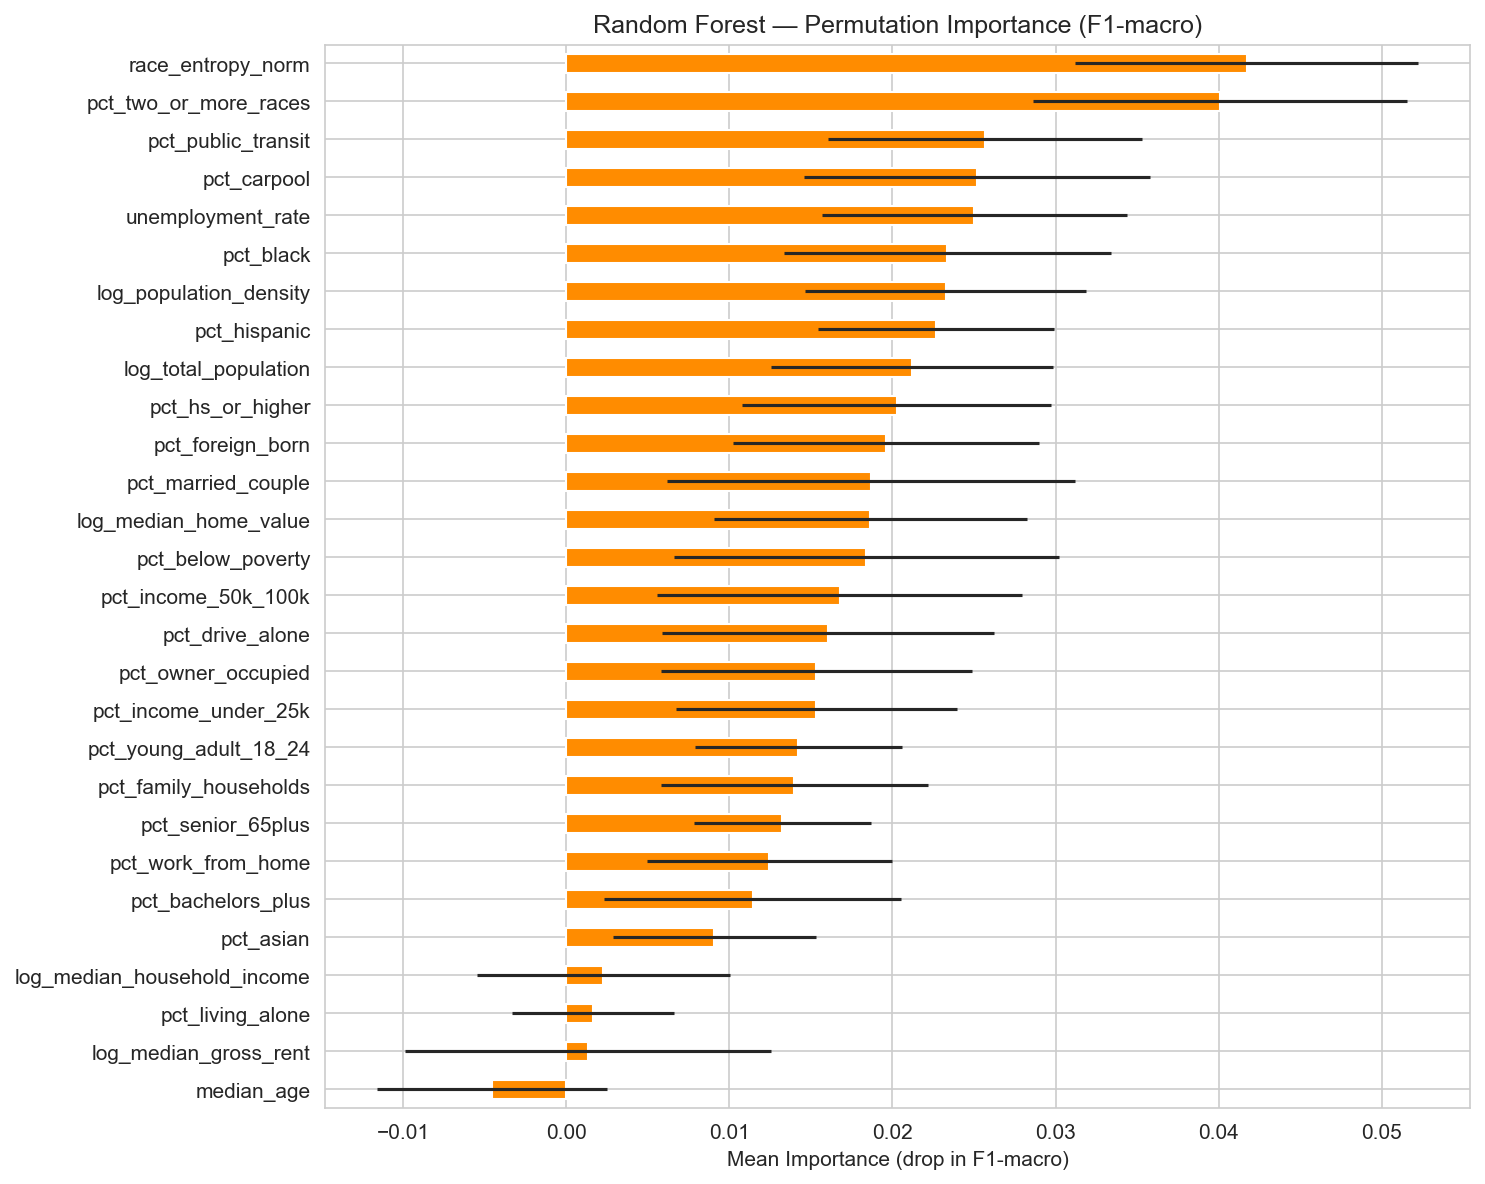

In [17]:
perm_result = permutation_importance(
    rf_final, X, y, n_repeats=30, random_state=RANDOM_STATE, scoring='f1_macro'
)

perm_imp_df = pd.DataFrame({
    'mean': perm_result.importances_mean,
    'std': perm_result.importances_std
}, index=feature_names).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
perm_imp_df['mean'].plot(kind='barh', xerr=perm_imp_df['std'], ax=ax, color='darkorange')
ax.set_title('Random Forest — Permutation Importance (F1-macro)')
ax.set_xlabel('Mean Importance (drop in F1-macro)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Hypothesis 2 — race_entropy_norm vs Individual Race Features

In [18]:
gini_ranked = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=False)
perm_ranked = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=False)

race_features = ['pct_black', 'pct_asian', 'pct_two_or_more_races', 'pct_hispanic', 'pct_foreign_born']
if 'pct_non_hispanic_white' in feature_names:
    race_features.append('pct_non_hispanic_white')

entropy_gini_rank = list(gini_ranked.index).index('race_entropy_norm') + 1
entropy_perm_rank = list(perm_ranked.index).index('race_entropy_norm') + 1

print('=== Hypothesis 2: race_entropy_norm vs Individual Race Features ===')
print(f'\nrace_entropy_norm — Gini rank: #{entropy_gini_rank}, Permutation rank: #{entropy_perm_rank}')
print(f'\nIndividual race feature ranks:')
print(f'{"Feature":<30} {"Gini Rank":>10} {"Gini Value":>12} {"Perm Rank":>10} {"Perm Value":>12}')
print('-' * 76)
for feat in ['race_entropy_norm'] + race_features:
    if feat in feature_names:
        g_rank = list(gini_ranked.index).index(feat) + 1
        p_rank = list(perm_ranked.index).index(feat) + 1
        print(f'{feat:<30} {g_rank:>10} {gini_ranked[feat]:>12.4f} {p_rank:>10} {perm_ranked[feat]:>12.4f}')

rf_pred_df = pd.DataFrame({
    'county_fips': county_fips_series.values,
    'rf_predicted_class': rf_preds,
    'actual_class': y
})
rf_pred_df.to_csv(f'{BASE}/rf_predictions.csv', index=False)
print(f'\nSaved RF predictions to {BASE}/rf_predictions.csv')

=== Hypothesis 2: race_entropy_norm vs Individual Race Features ===

race_entropy_norm — Gini rank: #2, Permutation rank: #1

Individual race feature ranks:
Feature                         Gini Rank   Gini Value  Perm Rank   Perm Value
----------------------------------------------------------------------------
race_entropy_norm                       2       0.0672          1       0.0417
pct_black                               5       0.0539          6       0.0234
pct_asian                              26       0.0169         24       0.0091
pct_two_or_more_races                   3       0.0582          2       0.0401
pct_hispanic                           14       0.0318          8       0.0227
pct_foreign_born                       21       0.0243         11       0.0196

Saved RF predictions to ../data/processed/rf_predictions.csv


---
## 4. Model B — XGBoost

### 4.1 Hyperparameter Tuning + Nested CV

In [19]:
y_xgb = y - 1

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 5.0]
}

print('XGBoost — Nested CV (5-fold outer, 3-fold inner, 100 iter):')
xgb_preds_0idx, xgb_proba, xgb_fold_metrics = nested_cv(
    X, y_xgb, xgb_base, xgb_param_grid, n_iter=100, model_name='XGBoost'
)

xgb_preds = xgb_preds_0idx + 1

print('\nBest params per fold:')
for fm in xgb_fold_metrics:
    print(f'  Fold {fm["fold"]+1}: {fm["best_params"]}')

XGBoost — Nested CV (5-fold outer, 3-fold inner, 100 iter):
  Fold 1: acc=0.300, F1-macro=0.317
  Fold 2: acc=0.360, F1-macro=0.348
  Fold 3: acc=0.380, F1-macro=0.380
  Fold 4: acc=0.440, F1-macro=0.388
  Fold 5: acc=0.460, F1-macro=0.469

Best params per fold:
  Fold 1: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
  Fold 2: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
  Fold 3: {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
  Fold 4: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  Fold 5: {'subsample': 0.9, 'reg_lambd

### 4.2 Evaluation Metrics

In [20]:
xgb_metrics = evaluate_model(y, xgb_preds, xgb_proba, y_binary, CLASS_NAMES, 'XGBoost')


=== XGBoost — Evaluation ===
Accuracy:        0.3880
Precision (macro): 0.3891
Recall (macro):    0.3880
F1-macro:          0.3874
ROC-AUC (binary):  0.7825

Per-class F1: {'Q1_VeryStable': np.float64(0.4158), 'Q2_Stable': np.float64(0.2157), 'Q3_Moderate': np.float64(0.3556), 'Q4_Volatile': np.float64(0.3619), 'Q5_HighlyVolatile': np.float64(0.5882)}

                   precision    recall  f1-score   support

    Q1_VeryStable       0.41      0.42      0.42        50
        Q2_Stable       0.21      0.22      0.22        50
      Q3_Moderate       0.40      0.32      0.36        50
      Q4_Volatile       0.35      0.38      0.36        50
Q5_HighlyVolatile       0.58      0.60      0.59        50

         accuracy                           0.39       250
        macro avg       0.39      0.39      0.39       250
     weighted avg       0.39      0.39      0.39       250



### 4.3 Confusion Matrix

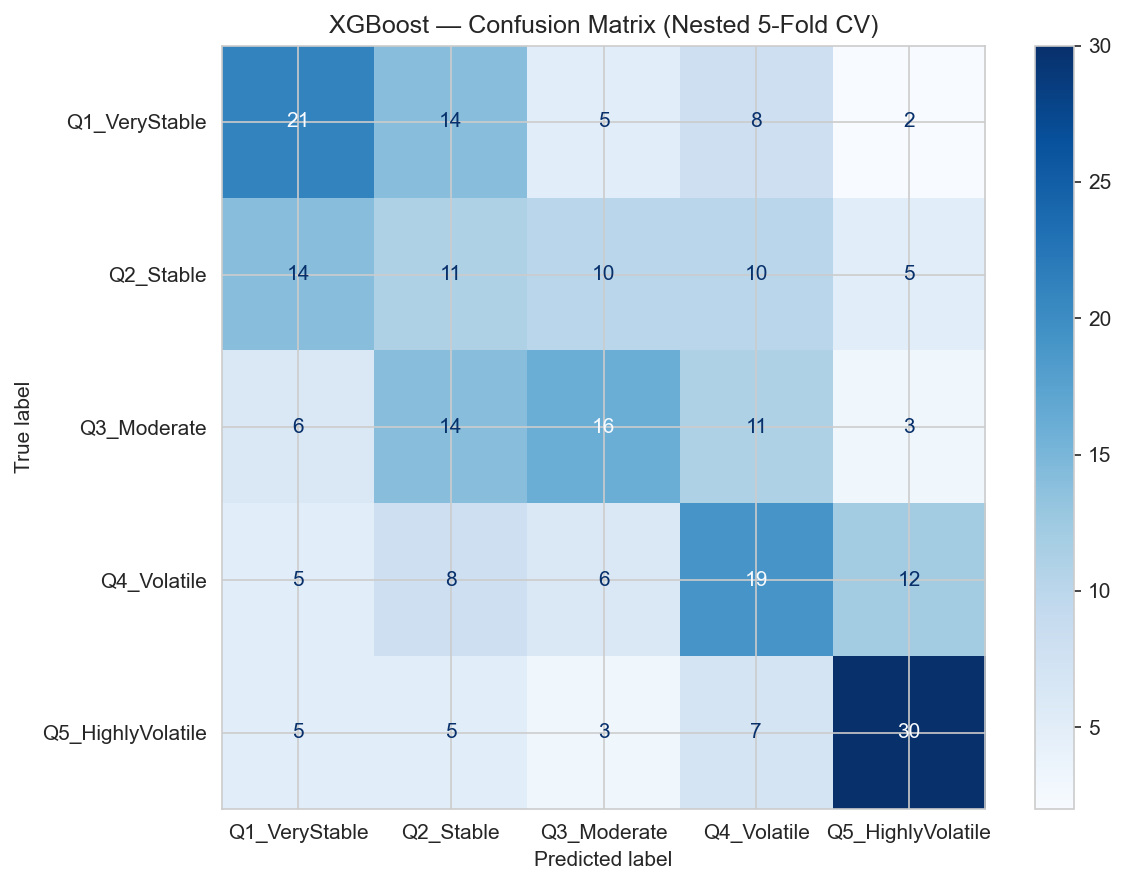

Saved: ../docs/images/methods/xgb_confusion_matrix.png


In [21]:
plot_confusion_matrix(
    y, xgb_preds, CLASS_NAMES,
    'XGBoost — Confusion Matrix (Nested 5-Fold CV)',
    f'{FIG_DIR}/xgb_confusion_matrix.png'
)

### 4.4 SHAP Summary Plot

SHAP values: array of shape (250, 28, 5)


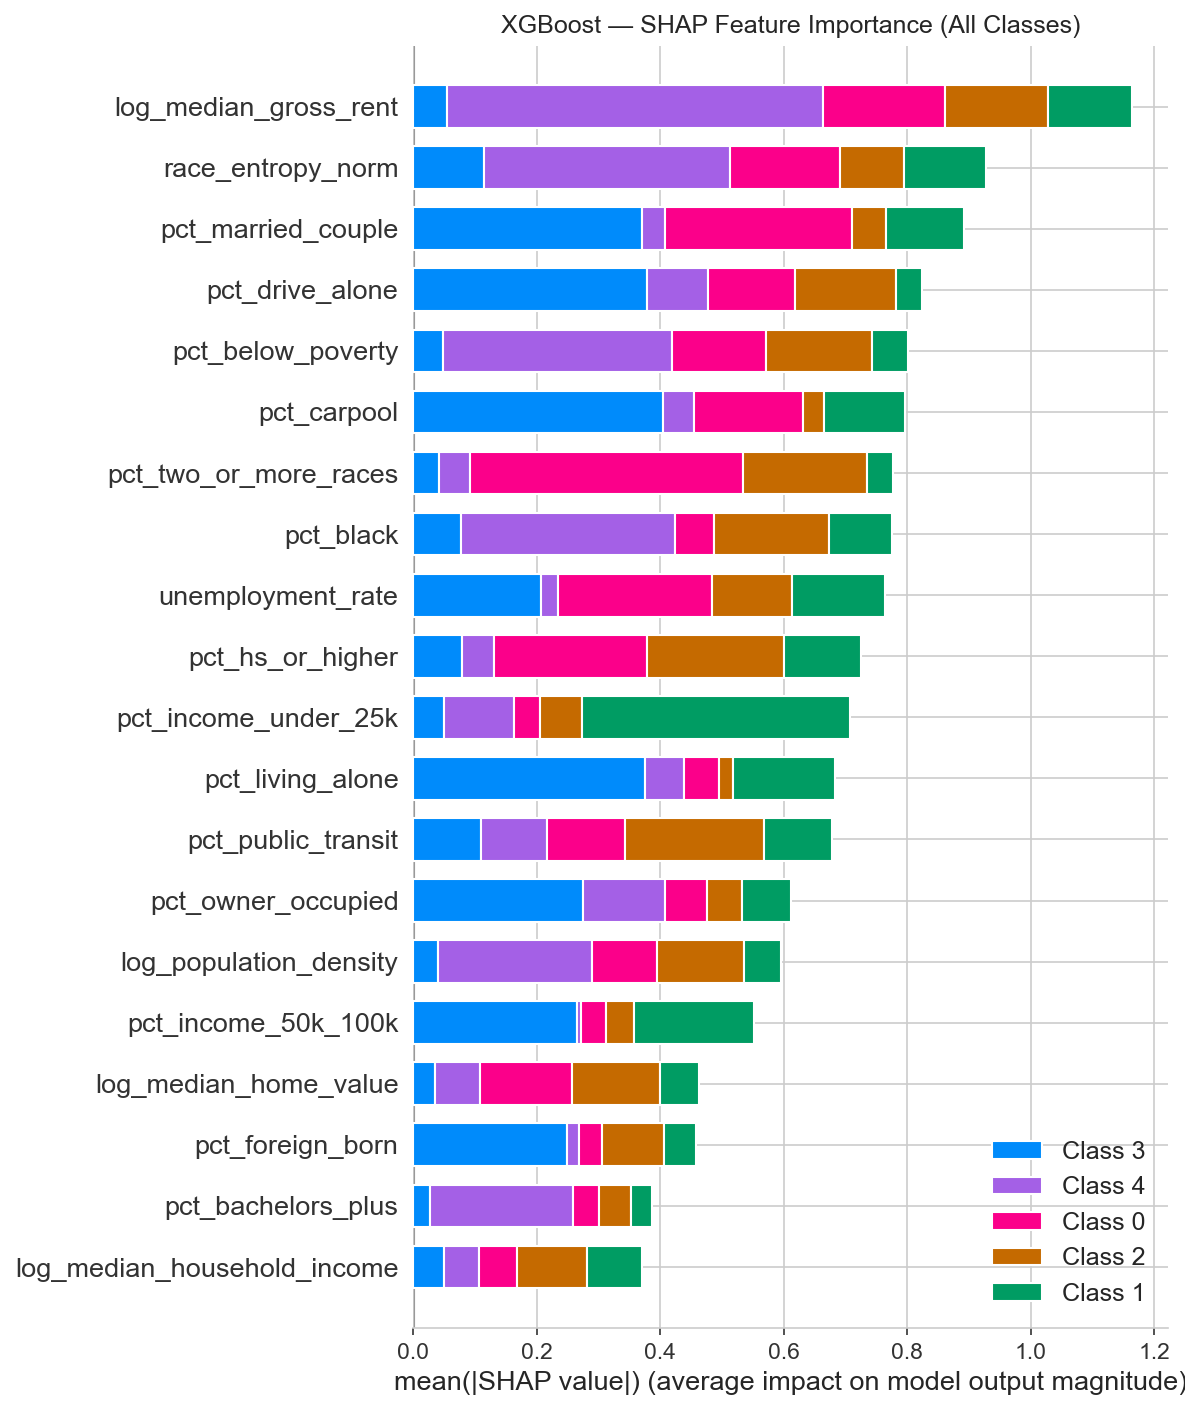

In [22]:
best_xgb_fold = max(range(len(xgb_fold_metrics)), key=lambda i: xgb_fold_metrics[i]['f1_macro'])
xgb_best_params = xgb_fold_metrics[best_xgb_fold]['best_params']

xgb_final = xgb.XGBClassifier(
    **xgb_best_params,
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_final.fit(X, y_xgb)

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    print(f'SHAP values: list of {len(shap_values)} arrays, each {shap_values[0].shape}')
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    print(f'SHAP values: array of shape {shap_values.shape}')
else:
    print(f'SHAP values type: {type(shap_values)}, shape: {shap_values.shape}')

fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type='bar', show=False, feature_names=feature_names)
plt.title('XGBoost — SHAP Feature Importance (All Classes)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 SHAP Dependence Plots — Top 5 Features (Class Q5 = Highly Volatile)

Top 5 features by mean |SHAP|: ['log_median_gross_rent', 'race_entropy_norm', 'pct_married_couple', 'pct_drive_alone', 'pct_below_poverty']


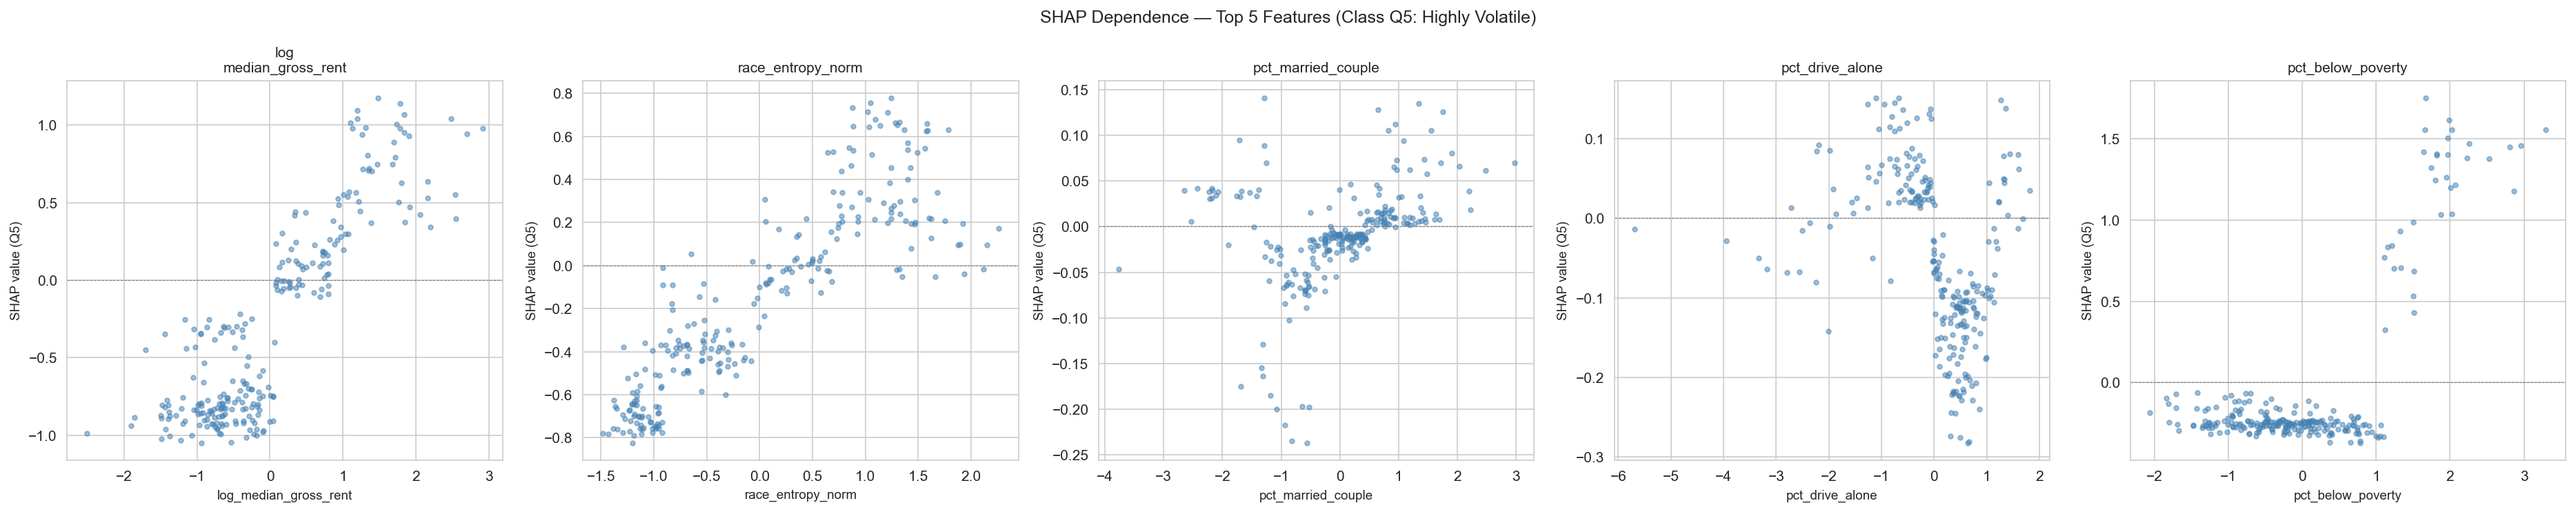

In [23]:
if isinstance(shap_values, list):
    q5_shap = shap_values[4]
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    q5_shap = shap_values[:, :, 4]
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    q5_shap = shap_values
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

top5_idx = np.argsort(mean_abs_shap)[-5:][::-1]
top5_features = [feature_names[i] for i in top5_idx]
print(f'Top 5 features by mean |SHAP|: {top5_features}')

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, feat in enumerate(top5_features):
    feat_idx = feature_names.index(feat)
    axes[i].scatter(X[feat].values, q5_shap[:, feat_idx], alpha=0.5, s=10, c='steelblue')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('SHAP value (Q5)', fontsize=9)
    axes[i].set_title(feat.replace('log_', 'log\n'), fontsize=10)
    axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('SHAP Dependence — Top 5 Features (Class Q5: Highly Volatile)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_shap_dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Hypothesis Tests via SHAP

In [24]:
print('=== Hypothesis 1: Volatility inversely correlated with wealth ===')
income_feat = 'log_median_household_income'
if income_feat in feature_names:
    income_idx = feature_names.index(income_feat)
    r_inc, p_inc = pearsonr(X[income_feat].values, q5_shap[:, income_idx])
    print(f'{income_feat} SHAP(Q5) correlation: r={r_inc:.3f}, p={p_inc:.4f}')
    if r_inc < 0:
        print('-> Negative r: higher income pushes AWAY from high volatility (SUPPORTS hypothesis)')
    else:
        print('-> Positive r: higher income pushes TOWARD high volatility (CONTRADICTS hypothesis)')

print('\n=== Hypothesis 2: race_entropy_norm vs individual race features (SHAP) ===')
entropy_idx = feature_names.index('race_entropy_norm')
entropy_shap_mean = np.abs(q5_shap[:, entropy_idx]).mean()

print(f'{"Feature":<30} {"Mean |SHAP| (Q5)":>18}')
print('-' * 50)
for feat in ['race_entropy_norm'] + race_features:
    if feat in feature_names:
        idx = feature_names.index(feat)
        val = np.abs(q5_shap[:, idx]).mean()
        marker = ' <-- ENTROPY' if feat == 'race_entropy_norm' else ''
        print(f'{feat:<30} {val:>18.4f}{marker}')

=== Hypothesis 1: Volatility inversely correlated with wealth ===
log_median_household_income SHAP(Q5) correlation: r=-0.602, p=0.0000
-> Negative r: higher income pushes AWAY from high volatility (SUPPORTS hypothesis)

=== Hypothesis 2: race_entropy_norm vs individual race features (SHAP) ===
Feature                          Mean |SHAP| (Q5)
--------------------------------------------------
race_entropy_norm                          0.3971 <-- ENTROPY
pct_black                                  0.3466
pct_asian                                  0.0157
pct_two_or_more_races                      0.0507
pct_hispanic                               0.0911
pct_foreign_born                           0.0194


---
## 5. Model C — SVM (Support Vector Machine)

SVM requires all-numerical, scaled input — our pipeline satisfies this.  
We compare **linear** vs **RBF** kernels to test whether the demographic-volatility boundary is linear or nonlinear.

### 5.1 Linear Kernel — Nested CV

In [25]:
svm_linear_base = SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)

svm_linear_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None]
}

print('SVM (Linear) — Nested CV:')
svm_lin_preds, svm_lin_proba, svm_lin_fold_metrics = nested_cv(
    X, y, svm_linear_base, svm_linear_grid, n_iter=10, model_name='SVM-Linear'
)

svm_lin_metrics = evaluate_model(y, svm_lin_preds, svm_lin_proba, y_binary, CLASS_NAMES, 'SVM (Linear)')

SVM (Linear) — Nested CV:
  Fold 1: acc=0.360, F1-macro=0.359
  Fold 2: acc=0.280, F1-macro=0.285
  Fold 3: acc=0.320, F1-macro=0.317
  Fold 4: acc=0.420, F1-macro=0.398
  Fold 5: acc=0.460, F1-macro=0.447

=== SVM (Linear) — Evaluation ===
Accuracy:        0.3680
Precision (macro): 0.3647
Recall (macro):    0.3680
F1-macro:          0.3641
ROC-AUC (binary):  0.7651

Per-class F1: {'Q1_VeryStable': np.float64(0.4561), 'Q2_Stable': np.float64(0.3654), 'Q3_Moderate': np.float64(0.1915), 'Q4_Volatile': np.float64(0.3441), 'Q5_HighlyVolatile': np.float64(0.4632)}

                   precision    recall  f1-score   support

    Q1_VeryStable       0.41      0.52      0.46        50
        Q2_Stable       0.35      0.38      0.37        50
      Q3_Moderate       0.20      0.18      0.19        50
      Q4_Volatile       0.37      0.32      0.34        50
Q5_HighlyVolatile       0.49      0.44      0.46        50

         accuracy                           0.37       250
        macro avg 

### 5.2 RBF Kernel — Nested CV

In [26]:
svm_rbf_base = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)

svm_rbf_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'class_weight': ['balanced', None]
}

print('SVM (RBF) — Nested CV:')
svm_rbf_preds, svm_rbf_proba, svm_rbf_fold_metrics = nested_cv(
    X, y, svm_rbf_base, svm_rbf_grid, n_iter=30, model_name='SVM-RBF'
)

svm_rbf_metrics = evaluate_model(y, svm_rbf_preds, svm_rbf_proba, y_binary, CLASS_NAMES, 'SVM (RBF)')

SVM (RBF) — Nested CV:
  Fold 1: acc=0.320, F1-macro=0.321
  Fold 2: acc=0.300, F1-macro=0.301
  Fold 3: acc=0.400, F1-macro=0.396
  Fold 4: acc=0.360, F1-macro=0.339
  Fold 5: acc=0.380, F1-macro=0.364

=== SVM (RBF) — Evaluation ===
Accuracy:        0.3520
Precision (macro): 0.3456
Recall (macro):    0.3520
F1-macro:          0.3468
ROC-AUC (binary):  0.7899

Per-class F1: {'Q1_VeryStable': np.float64(0.4545), 'Q2_Stable': np.float64(0.2264), 'Q3_Moderate': np.float64(0.3168), 'Q4_Volatile': np.float64(0.1647), 'Q5_HighlyVolatile': np.float64(0.5714)}

                   precision    recall  f1-score   support

    Q1_VeryStable       0.42      0.50      0.45        50
        Q2_Stable       0.21      0.24      0.23        50
      Q3_Moderate       0.31      0.32      0.32        50
      Q4_Volatile       0.20      0.14      0.16        50
Q5_HighlyVolatile       0.58      0.56      0.57        50

         accuracy                           0.35       250
        macro avg       

### 5.3 Kernel Comparison

In [27]:
kernel_comp = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-macro', 'ROC-AUC (binary)'],
    'Linear': [
        svm_lin_metrics['accuracy'], svm_lin_metrics['precision_macro'],
        svm_lin_metrics['recall_macro'], svm_lin_metrics['f1_macro'],
        svm_lin_metrics['roc_auc_binary']
    ],
    'RBF': [
        svm_rbf_metrics['accuracy'], svm_rbf_metrics['precision_macro'],
        svm_rbf_metrics['recall_macro'], svm_rbf_metrics['f1_macro'],
        svm_rbf_metrics['roc_auc_binary']
    ]
})
print('=== SVM Kernel Comparison ===')
print(kernel_comp.to_string(index=False))

if svm_rbf_metrics['f1_macro'] >= svm_lin_metrics['f1_macro']:
    svm_best_kernel = 'RBF'
    svm_preds = svm_rbf_preds
    svm_proba = svm_rbf_proba
    svm_metrics = svm_rbf_metrics
    svm_fold_metrics = svm_rbf_fold_metrics
    print('\n-> RBF kernel selected (higher F1-macro)')
    if svm_rbf_metrics['f1_macro'] > svm_lin_metrics['f1_macro'] + 0.02:
        print('   Substantial gap: demographic-volatility boundary appears NONLINEAR')
else:
    svm_best_kernel = 'Linear'
    svm_preds = svm_lin_preds
    svm_proba = svm_lin_proba
    svm_metrics = svm_lin_metrics
    svm_fold_metrics = svm_lin_fold_metrics
    print('\n-> Linear kernel selected (higher F1-macro)')
    print('   Demographic-volatility boundary appears approximately LINEAR')

=== SVM Kernel Comparison ===
           Metric   Linear      RBF
         Accuracy 0.368000 0.352000
Precision (macro) 0.364726 0.345602
   Recall (macro) 0.368000 0.352000
         F1-macro 0.364052 0.346785
 ROC-AUC (binary) 0.765067 0.789933

-> Linear kernel selected (higher F1-macro)
   Demographic-volatility boundary appears approximately LINEAR


### 5.4 Confusion Matrix (Best Kernel)

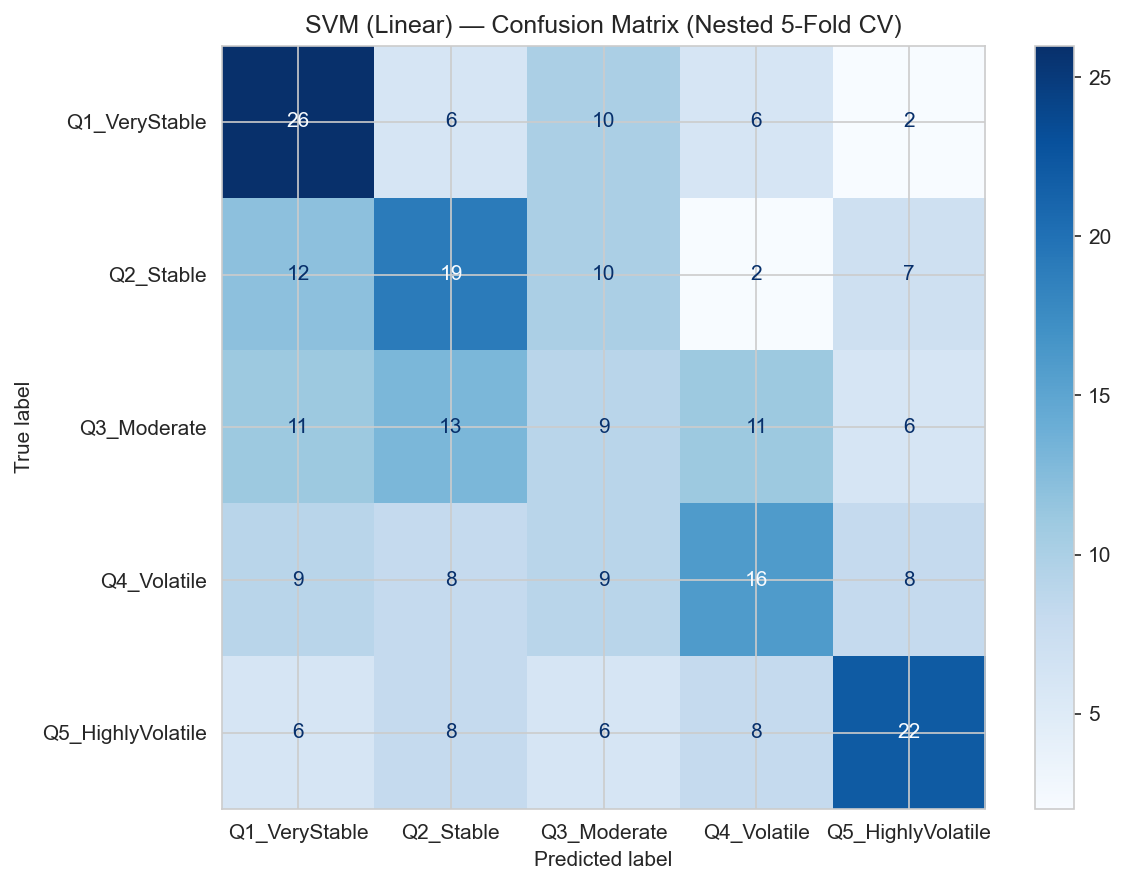

Saved: ../docs/images/methods/svm_confusion_matrix.png


In [28]:
plot_confusion_matrix(
    y, svm_preds, CLASS_NAMES,
    f'SVM ({svm_best_kernel}) — Confusion Matrix (Nested 5-Fold CV)',
    f'{FIG_DIR}/svm_confusion_matrix.png'
)

---
## 6. Model D — Demographic Misfit Detector

This model predicts **partisan lean** from demographics, then analyzes **prediction errors** to identify counties whose electoral behavior defies their demographic profile.

### 6.1 Binary Target Construction

In [29]:
df_misfit = pd.DataFrame({
    'county_fips': county_fips_series.values,
    'state': state_series.values,
    'county_name': county_name_series.values,
    'dem_margin': dem_margin_series.values,
    'vol_z_abs_sum': df['vol_z_abs_sum'].values,
    'swing_dir_score': df['swing_dir_score'].values,
    'volatility_class': y_labels,
    'vol_quintile_num': y
})

df_misfit['dem_winner'] = (df_misfit['dem_margin'] > 0).astype(int)

print(f'Dem-won counties: {df_misfit["dem_winner"].sum()}')
print(f'Rep-won counties: {(1 - df_misfit["dem_winner"]).sum()}')
print(f'Class balance: {df_misfit["dem_winner"].mean():.2%} Dem')

Dem-won counties: 40
Rep-won counties: 210
Class balance: 16.00% Dem


### 6.2 Logistic Regression — Cross-Validated P(Dem)

In [30]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

cv_misfit = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_proba = cross_val_predict(
    lr, X, df_misfit['dem_winner'],
    cv=cv_misfit, method='predict_proba'
)

df_misfit['p_dem'] = cv_proba[:, 1]

cv_preds_lr = cross_val_predict(lr, X, df_misfit['dem_winner'], cv=cv_misfit)
lr_acc = accuracy_score(df_misfit['dem_winner'], cv_preds_lr)
lr_f1 = f1_score(df_misfit['dem_winner'], cv_preds_lr, average='macro')
print(f'Logistic Regression CV — Accuracy: {lr_acc:.4f}, F1-macro: {lr_f1:.4f}')
print(f'P(Dem) range: [{df_misfit["p_dem"].min():.3f}, {df_misfit["p_dem"].max():.3f}]')

Logistic Regression CV — Accuracy: 0.8960, F1-macro: 0.8268
P(Dem) range: [0.000, 1.000]


### 6.3 Compute Residuals

In [31]:
df_misfit['class_residual'] = df_misfit['dem_winner'] - df_misfit['p_dem']
df_misfit['misfit_score'] = df_misfit['class_residual'].abs()

df_misfit['actual_dem_norm'] = (df_misfit['dem_margin'] / 100 + 1) / 2
df_misfit['margin_residual'] = df_misfit['actual_dem_norm'] - df_misfit['p_dem']
df_misfit['abs_margin_residual'] = df_misfit['margin_residual'].abs()

print('Residual summary:')
print(df_misfit[['misfit_score', 'abs_margin_residual']].describe().round(4))

Residual summary:
       misfit_score  abs_margin_residual
count      250.0000             250.0000
mean         0.1171               0.2917
std          0.2314               0.0936
min          0.0000               0.0023
25%          0.0008               0.2405
50%          0.0062               0.2961
75%          0.0777               0.3508
max          0.9563               0.4994


### 6.4 Layer 1 — Prediction Uncertainty (P(Dem) closest to 0.5)

In [32]:
df_misfit['uncertainty'] = (df_misfit['p_dem'] - 0.5).abs()

uncertain = df_misfit.nsmallest(15, 'uncertainty')
print('=== Layer 1: Top 15 Most Uncertain Counties (demographics give no clear signal) ===')
print(uncertain[['county_name', 'state', 'p_dem', 'dem_margin', 'uncertainty',
                  'volatility_class']].to_string(index=False))

=== Layer 1: Top 15 Most Uncertain Counties (demographics give no clear signal) ===
          county_name state    p_dem  dem_margin  uncertainty volatility_class
        Wilson County    NC 0.504327    0.397053     0.004327         Moderate
      Houghton County    MI 0.506982  -17.033137     0.006982         Moderate
       Berrien County    MI 0.525602   -7.873307     0.025602         Moderate
      Mackinac County    MI 0.534690  -24.882564     0.034690         Moderate
        Craven County    NC 0.465018  -20.411942     0.034982         Moderate
   Northampton County    PA 0.457076   -1.774261     0.042924         Volatile
          Dare County    NC 0.544858  -18.725194     0.044858         Volatile
      Keweenaw County    MI 0.444725  -12.787089     0.055275         Volatile
        Chowan County    NC 0.436149  -22.404661     0.063851  Highly Volatile
Grand Traverse County    MI 0.567215   -1.726885     0.067215  Highly Volatile
        Butler County    PA 0.417985  -32.20685

### 6.5 Layer 2 — Top 15 Demographic Misfits

In [33]:
misfits = df_misfit.nlargest(15, 'misfit_score')

print('=== Layer 2: Top 15 Demographic Misfits ===')
print('Counties where electoral behavior most defies demographic expectations:\n')
display_cols = ['county_name', 'state', 'p_dem', 'dem_winner', 'dem_margin',
                'misfit_score', 'vol_z_abs_sum', 'volatility_class']
print(misfits[display_cols].to_string(index=False))

print('\nInterpretation:')
for _, row in misfits.head(5).iterrows():
    direction = 'more Dem' if row['class_residual'] > 0 else 'more Rep'
    print(f"  {row['county_name']} ({row['state']}): P(Dem)={row['p_dem']:.2f}, "
          f"actual={'Dem' if row['dem_winner'] else 'Rep'} — {direction} than demographics predict")

=== Layer 2: Top 15 Demographic Misfits ===
Counties where electoral behavior most defies demographic expectations:

      county_name state    p_dem  dem_winner  dem_margin  misfit_score  vol_z_abs_sum volatility_class
  Leelanau County    MI 0.043672           1    7.752332      0.956328       2.256613  Highly Volatile
 Marquette County    MI 0.044232           1    8.733882      0.955768       1.588221  Highly Volatile
      Nash County    NC 0.945914           0   -1.759067      0.945914      -1.377242      Very Stable
    Lenoir County    NC 0.935390           0   -6.777442      0.935390      -0.805879           Stable
  Cabarrus County    NC 0.865609           0   -7.697043      0.865609       2.619199  Highly Volatile
  Isabella County    MI 0.864896           0   -7.488244      0.864896       0.433367         Volatile
     Wayne County    NC 0.847685           0  -16.365363      0.847685      -0.068221         Moderate
   Genesee County    MI 0.177247           1    4.195406   

### 6.6 Layer 3 — Residual x Volatility x Swing Direction

=== Layer 3: Cross-Analysis Correlations ===
Pair                                           Pearson r    p-value Spearman rho    p-value
------------------------------------------------------------------------------------------
misfit_score vs vol_z_abs_sum             0.213     0.0007        0.408     0.0000
misfit_score vs swing_dir_score          -0.017     0.7870        0.004     0.9522
vol_z_abs_sum vs swing_dir_score           0.487     0.0000        0.144     0.0231
abs_margin_residual vs vol_z_abs_sum             0.100     0.1129        0.156     0.0134


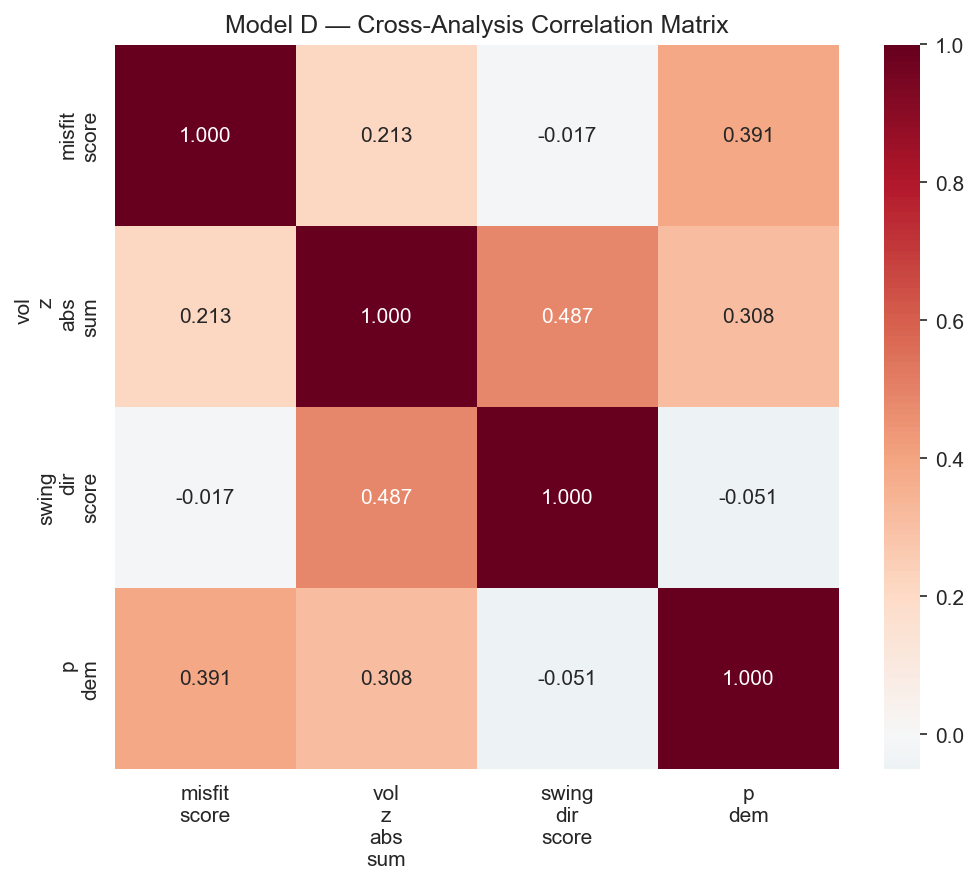

In [34]:
analysis_cols = ['misfit_score', 'vol_z_abs_sum', 'swing_dir_score', 'p_dem']

print('=== Layer 3: Cross-Analysis Correlations ===')
pairs = [
    ('misfit_score', 'vol_z_abs_sum'),
    ('misfit_score', 'swing_dir_score'),
    ('vol_z_abs_sum', 'swing_dir_score'),
    ('abs_margin_residual', 'vol_z_abs_sum'),
]

print(f'{"Pair":<45} {"Pearson r":>10} {"p-value":>10} {"Spearman rho":>12} {"p-value":>10}')
print('-' * 90)
for a, b in pairs:
    r, p = pearsonr(df_misfit[a], df_misfit[b])
    rho, p_s = spearmanr(df_misfit[a], df_misfit[b])
    print(f'{a} vs {b:<20} {r:>10.3f} {p:>10.4f} {rho:>12.3f} {p_s:>10.4f}')

corr_matrix = df_misfit[analysis_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=[c.replace('_', '\n') for c in analysis_cols],
            yticklabels=[c.replace('_', '\n') for c in analysis_cols])
ax.set_title('Model D — Cross-Analysis Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/misfit_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.7 Scatter Plot — P(Dem) vs Actual Dem Margin

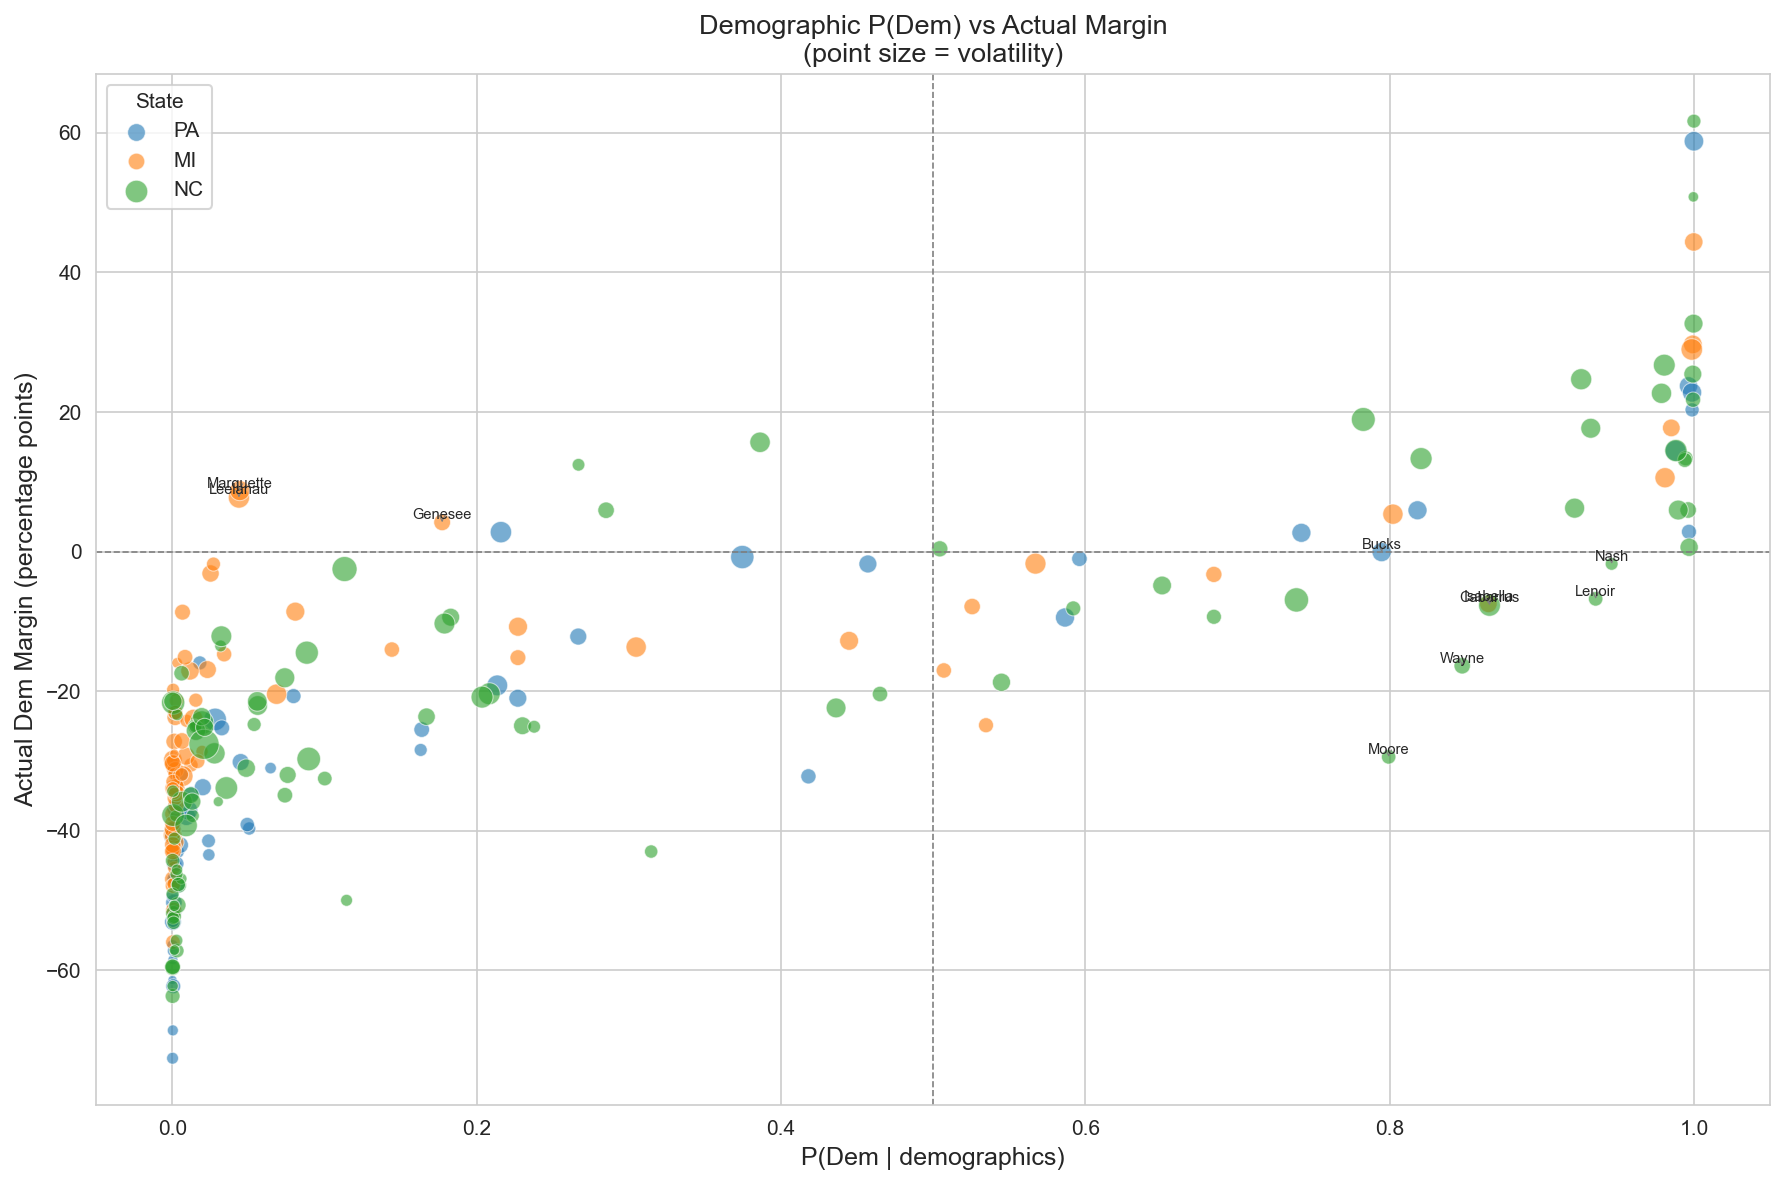

In [35]:
vol_shifted = df_misfit['vol_z_abs_sum'] - df_misfit['vol_z_abs_sum'].min() + 0.5
size_scale = (vol_shifted / vol_shifted.max()) * 200 + 10

fig, ax = plt.subplots(figsize=(12, 8))

colors = {'PA': '#1f77b4', 'MI': '#ff7f0e', 'NC': '#2ca02c'}
for state_name, color in colors.items():
    mask = df_misfit['state'] == state_name
    ax.scatter(
        df_misfit.loc[mask, 'p_dem'],
        df_misfit.loc[mask, 'dem_margin'],
        s=size_scale[mask],
        c=color, alpha=0.6, edgecolors='white', linewidth=0.5,
        label=state_name
    )

for _, row in misfits.head(10).iterrows():
    ax.annotate(
        row['county_name'].replace(' County', ''),
        (row['p_dem'], row['dem_margin']),
        fontsize=7, ha='center', va='bottom',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.5)
    )

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('P(Dem | demographics)', fontsize=12)
ax.set_ylabel('Actual Dem Margin (percentage points)', fontsize=12)
ax.set_title('Demographic P(Dem) vs Actual Margin\n(point size = volatility)', fontsize=13)
ax.legend(title='State', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/misfit_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Cross-State Generalization Experiment

### 7.1 Identify Best Model from A/B/C

In [36]:
model_f1_scores = {
    'Random Forest': rf_metrics['f1_macro'],
    'XGBoost': xgb_metrics['f1_macro'],
    f'SVM ({svm_best_kernel})': svm_metrics['f1_macro']
}

best_model_name = max(model_f1_scores, key=model_f1_scores.get)
best_f1 = model_f1_scores[best_model_name]
print(f'Best model: {best_model_name} (F1-macro = {best_f1:.4f})')
print(f'All F1 scores: {model_f1_scores}')

Best model: XGBoost (F1-macro = 0.3874)
All F1 scores: {'Random Forest': 0.3618970686345814, 'XGBoost': 0.3874446940492369, 'SVM (Linear)': 0.36405164884123087}


### 7.2 Leave-One-State-Out Experiment

In [37]:
if 'Random Forest' in best_model_name:
    best_class = RandomForestClassifier
    best_params = rf_best_params.copy()
    loso_y = y
elif 'XGBoost' in best_model_name:
    best_class = xgb.XGBClassifier
    best_params = xgb_best_params.copy()
    best_params.update({'objective': 'multi:softprob', 'num_class': 5,
                        'eval_metric': 'mlogloss', 'verbosity': 0})
    loso_y = y - 1
else:
    best_class = SVC
    best_fold = max(range(len(svm_fold_metrics)), key=lambda i: svm_fold_metrics[i]['f1_macro'])
    best_params = svm_fold_metrics[best_fold]['best_params'].copy()
    best_params['probability'] = True
    best_params['kernel'] = svm_best_kernel.lower()
    loso_y = y

loso_results = {}
unique_states = state_series.unique()

for test_state in sorted(unique_states):
    train_mask = state_series != test_state
    test_mask = state_series == test_state

    X_train_raw = X_unscaled[train_mask]
    X_test_raw = X_unscaled[test_mask]
    y_train = loso_y[train_mask]
    y_test = loso_y[test_mask]

    loso_scaler = StandardScaler()
    X_train_s = pd.DataFrame(loso_scaler.fit_transform(X_train_raw),
                              columns=feature_names)
    X_test_s = pd.DataFrame(loso_scaler.transform(X_test_raw),
                             columns=feature_names)

    model = best_class(**best_params, random_state=RANDOM_STATE)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)

    if 'XGBoost' in best_model_name:
        preds_eval = preds + 1
        y_test_eval = y_test + 1
    else:
        preds_eval = preds
        y_test_eval = y_test

    loso_results[test_state] = {
        'accuracy': accuracy_score(y_test_eval, preds_eval),
        'f1_macro': f1_score(y_test_eval, preds_eval, average='macro'),
        'n_train': train_mask.sum(),
        'n_test': test_mask.sum(),
        'y_test': y_test_eval,
        'preds': preds_eval
    }
    print(f'Test: {test_state} (n={test_mask.sum()}) — '
          f'Acc={loso_results[test_state]["accuracy"]:.3f}, '
          f'F1={loso_results[test_state]["f1_macro"]:.3f}')

Test: MI (n=83) — Acc=0.205, F1=0.182
Test: NC (n=100) — Acc=0.210, F1=0.213
Test: PA (n=67) — Acc=0.209, F1=0.189


### 7.3 LOSO Confusion Matrices + Comparison

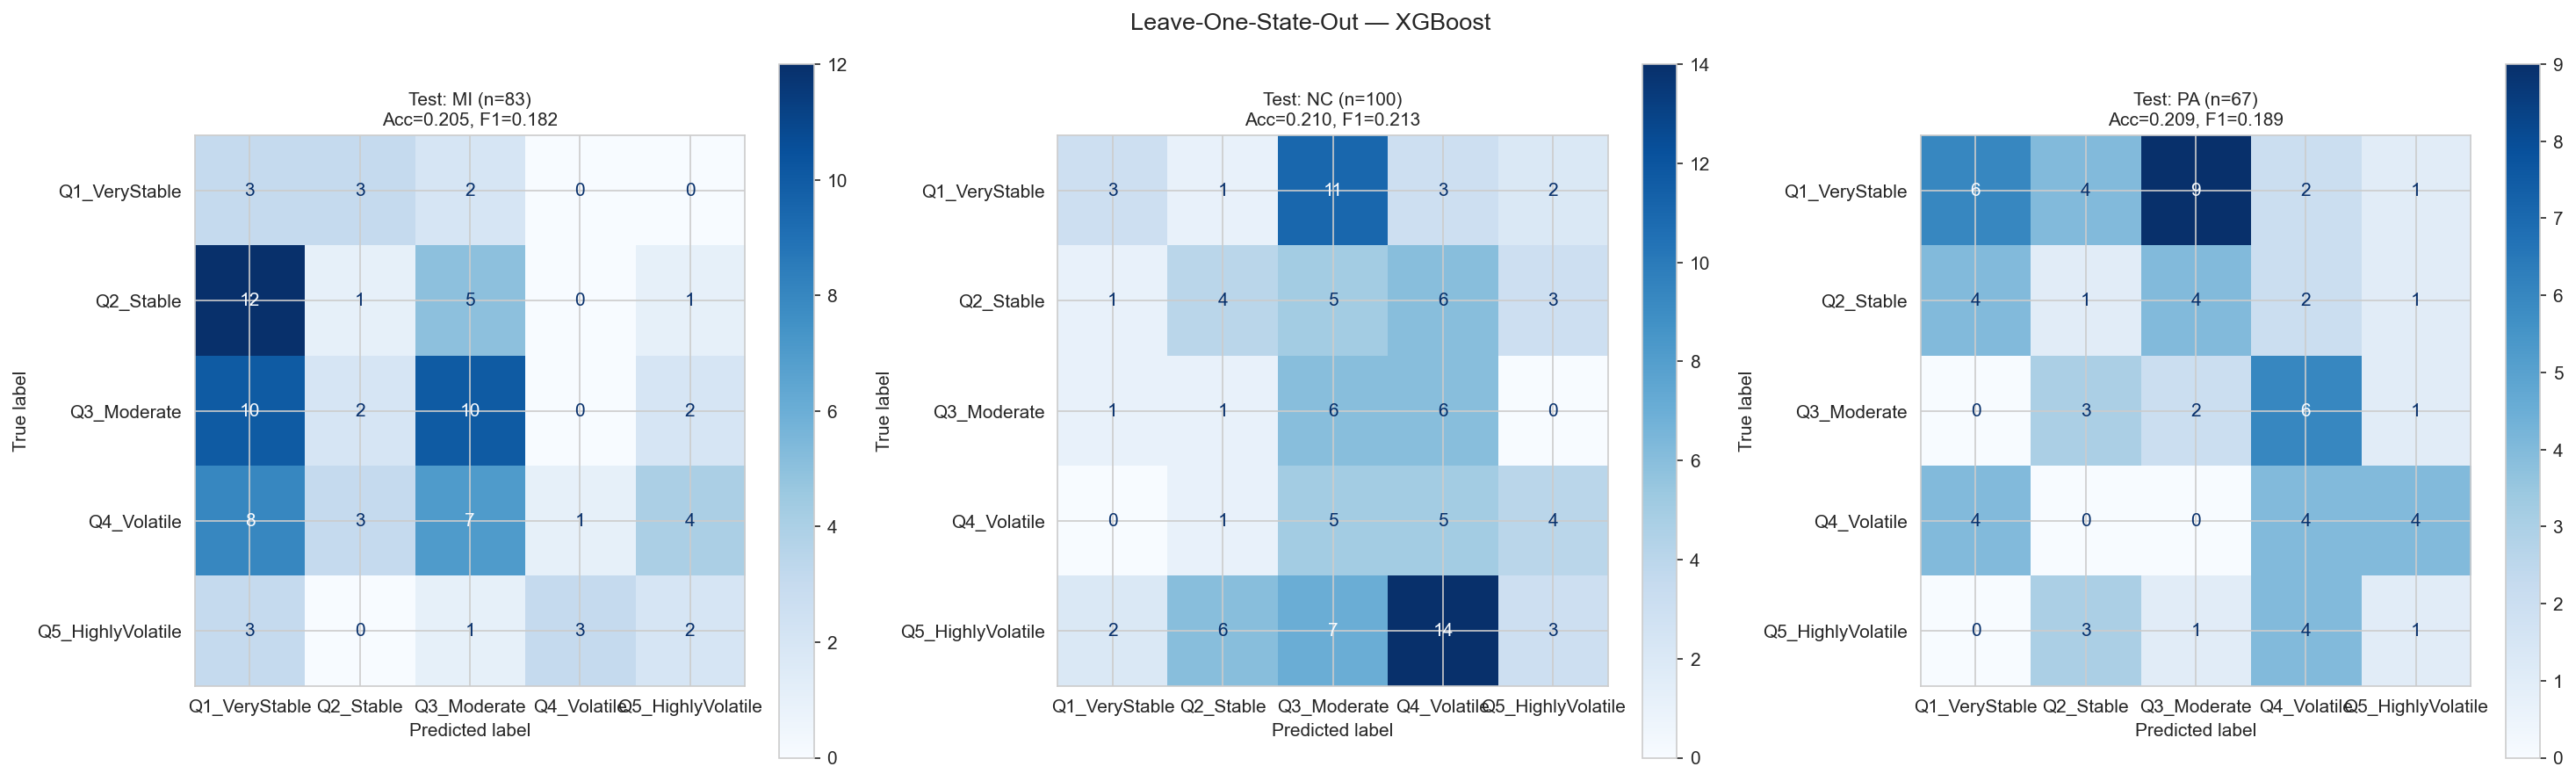


=== LOSO vs Full-CV Comparison ===
Full-dataset CV F1-macro:  0.3874
LOSO average F1-macro:     0.1948
Gap:                       0.1926
-> Notable gap: state-specific factors matter; volatility drivers vary by state


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (state_name, res) in enumerate(sorted(loso_results.items())):
    ConfusionMatrixDisplay.from_predictions(
        res['y_test'], res['preds'],
        display_labels=CLASS_NAMES, cmap='Blues', ax=axes[i]
    )
    axes[i].set_title(f'Test: {state_name} (n={res["n_test"]})\n'
                      f'Acc={res["accuracy"]:.3f}, F1={res["f1_macro"]:.3f}',
                      fontsize=10)

plt.suptitle(f'Leave-One-State-Out — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/loso_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== LOSO vs Full-CV Comparison ===')
loso_avg_f1 = np.mean([r['f1_macro'] for r in loso_results.values()])
print(f'Full-dataset CV F1-macro:  {best_f1:.4f}')
print(f'LOSO average F1-macro:     {loso_avg_f1:.4f}')
print(f'Gap:                       {best_f1 - loso_avg_f1:.4f}')
if best_f1 - loso_avg_f1 < 0.05:
    print('-> Small gap: demographic predictors GENERALIZE well across state lines')
else:
    print('-> Notable gap: state-specific factors matter; volatility drivers vary by state')

---
## 8. Model Comparison Summary

### 8.1 Side-by-Side Metrics

In [39]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', f'SVM ({svm_best_kernel})', 'Logistic (Misfit)'],
    'Accuracy': [rf_metrics['accuracy'], xgb_metrics['accuracy'],
                 svm_metrics['accuracy'], lr_acc],
    'Precision (macro)': [rf_metrics['precision_macro'], xgb_metrics['precision_macro'],
                          svm_metrics['precision_macro'], None],
    'Recall (macro)': [rf_metrics['recall_macro'], xgb_metrics['recall_macro'],
                       svm_metrics['recall_macro'], None],
    'F1-macro': [rf_metrics['f1_macro'], xgb_metrics['f1_macro'],
                 svm_metrics['f1_macro'], lr_f1],
    'ROC-AUC (binary)': [rf_metrics['roc_auc_binary'], xgb_metrics['roc_auc_binary'],
                         svm_metrics['roc_auc_binary'], None]
})

print('=== Model Comparison (5-class volatility prediction) ===')
print(comparison_df.to_string(index=False))

best_overall = comparison_df.iloc[:3].sort_values('F1-macro', ascending=False).iloc[0]
print(f'\nBest classification model: {best_overall["Model"]} (F1-macro = {best_overall["F1-macro"]:.4f})')

=== Model Comparison (5-class volatility prediction) ===
            Model  Accuracy  Precision (macro)  Recall (macro)  F1-macro  ROC-AUC (binary)
    Random Forest     0.368           0.358098           0.368  0.361897          0.803133
          XGBoost     0.388           0.389136           0.388  0.387445          0.782533
     SVM (Linear)     0.368           0.364726           0.368  0.364052          0.765067
Logistic (Misfit)     0.896                NaN             NaN  0.826833               NaN

Best classification model: XGBoost (F1-macro = 0.3874)


### 8.2 Per-Class F1 Heatmap

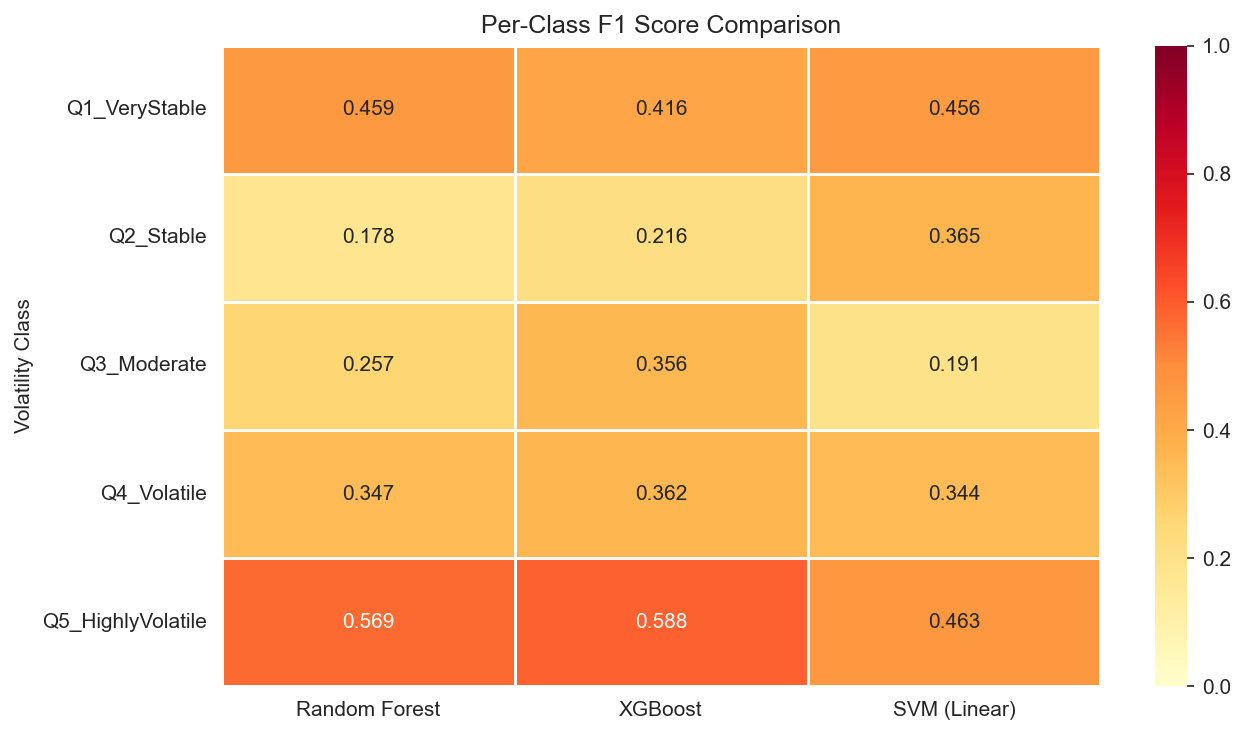


Per-class F1 scores:
                   Random Forest  XGBoost  SVM (Linear)
Q1_VeryStable              0.459    0.416         0.456
Q2_Stable                  0.178    0.216         0.365
Q3_Moderate                0.257    0.356         0.191
Q4_Volatile                0.347    0.362         0.344
Q5_HighlyVolatile          0.569    0.588         0.463


In [40]:
per_class_df = pd.DataFrame({
    'Random Forest': rf_metrics['f1_per_class'],
    'XGBoost': xgb_metrics['f1_per_class'],
    f'SVM ({svm_best_kernel})': svm_metrics['f1_per_class']
}, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(per_class_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Per-Class F1 Score Comparison')
ax.set_ylabel('Volatility Class')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class F1 scores:')
print(per_class_df.round(3))

### 8.3 Save All Predictions

In [41]:
predictions_df = pd.DataFrame({
    'county_fips': county_fips_series.values,
    'state': state_series.values,
    'county_name': county_name_series.values,
    'actual_quintile': y,
    'rf_pred': rf_preds,
    'xgb_pred': xgb_preds,
    'svm_pred': svm_preds,
    'p_dem': df_misfit['p_dem'].values,
    'misfit_score': df_misfit['misfit_score'].values,
    'abs_margin_residual': df_misfit['abs_margin_residual'].values
})

predictions_df.to_csv(f'{BASE}/classification_predictions.csv', index=False)
print(f'Saved: {BASE}/classification_predictions.csv ({predictions_df.shape})')
print(predictions_df.head())

Saved: ../data/processed/classification_predictions.csv ((250, 10))
  county_fips state     county_name  actual_quintile  rf_pred  xgb_pred  \
0       26001    MI   Alcona County                3        1         1   
1       26003    MI    Alger County                2        4         4   
2       26005    MI  Allegan County                3        2         1   
3       26007    MI   Alpena County                1        3         4   
4       26009    MI   Antrim County                3        3         4   

   svm_pred     p_dem  misfit_score  abs_margin_residual  
0         2  0.002292      0.002292             0.289436  
1         4  0.000409      0.000409             0.400599  
2         4  0.001124      0.001124             0.362816  
3         4  0.019426      0.019426             0.337398  
4         2  0.001761      0.001761             0.379450  


---
## 9. Choropleth Maps

### 9.1 Load GeoJSON and Prepare Data

In [42]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'
with urlopen(url) as response:
    counties_geojson = json.loads(response.read())

gdf = gpd.GeoDataFrame.from_features(counties_geojson['features'])
gdf = gdf.rename(columns={'id': 'county_fips'})

if 'county_fips' not in gdf.columns:
    gdf['county_fips'] = [f['id'] for f in counties_geojson['features']]

gdf['county_fips'] = gdf['county_fips'].astype(str).str.zfill(5)

state_fips_prefixes = {'PA': '42', 'MI': '26', 'NC': '37'}
all_prefixes = list(state_fips_prefixes.values())
gdf_3states = gdf[gdf['county_fips'].str[:2].isin(all_prefixes)].copy()

predictions_df['county_fips'] = predictions_df['county_fips'].astype(str).str.zfill(5)
geo_merged = gdf_3states.merge(predictions_df, on='county_fips', how='left')

misfit_merged = gdf_3states.merge(
    df_misfit[['county_fips', 'misfit_score', 'abs_margin_residual']],
    on='county_fips', how='left'
)

print(f'GeoJSON features for 3 states: {len(gdf_3states)}')
print(f'Matched counties: {geo_merged["actual_quintile"].notna().sum()}')

GeoJSON features for 3 states: 250
Matched counties: 250


### 9.2 Map 1 — Predicted Volatility Class by County

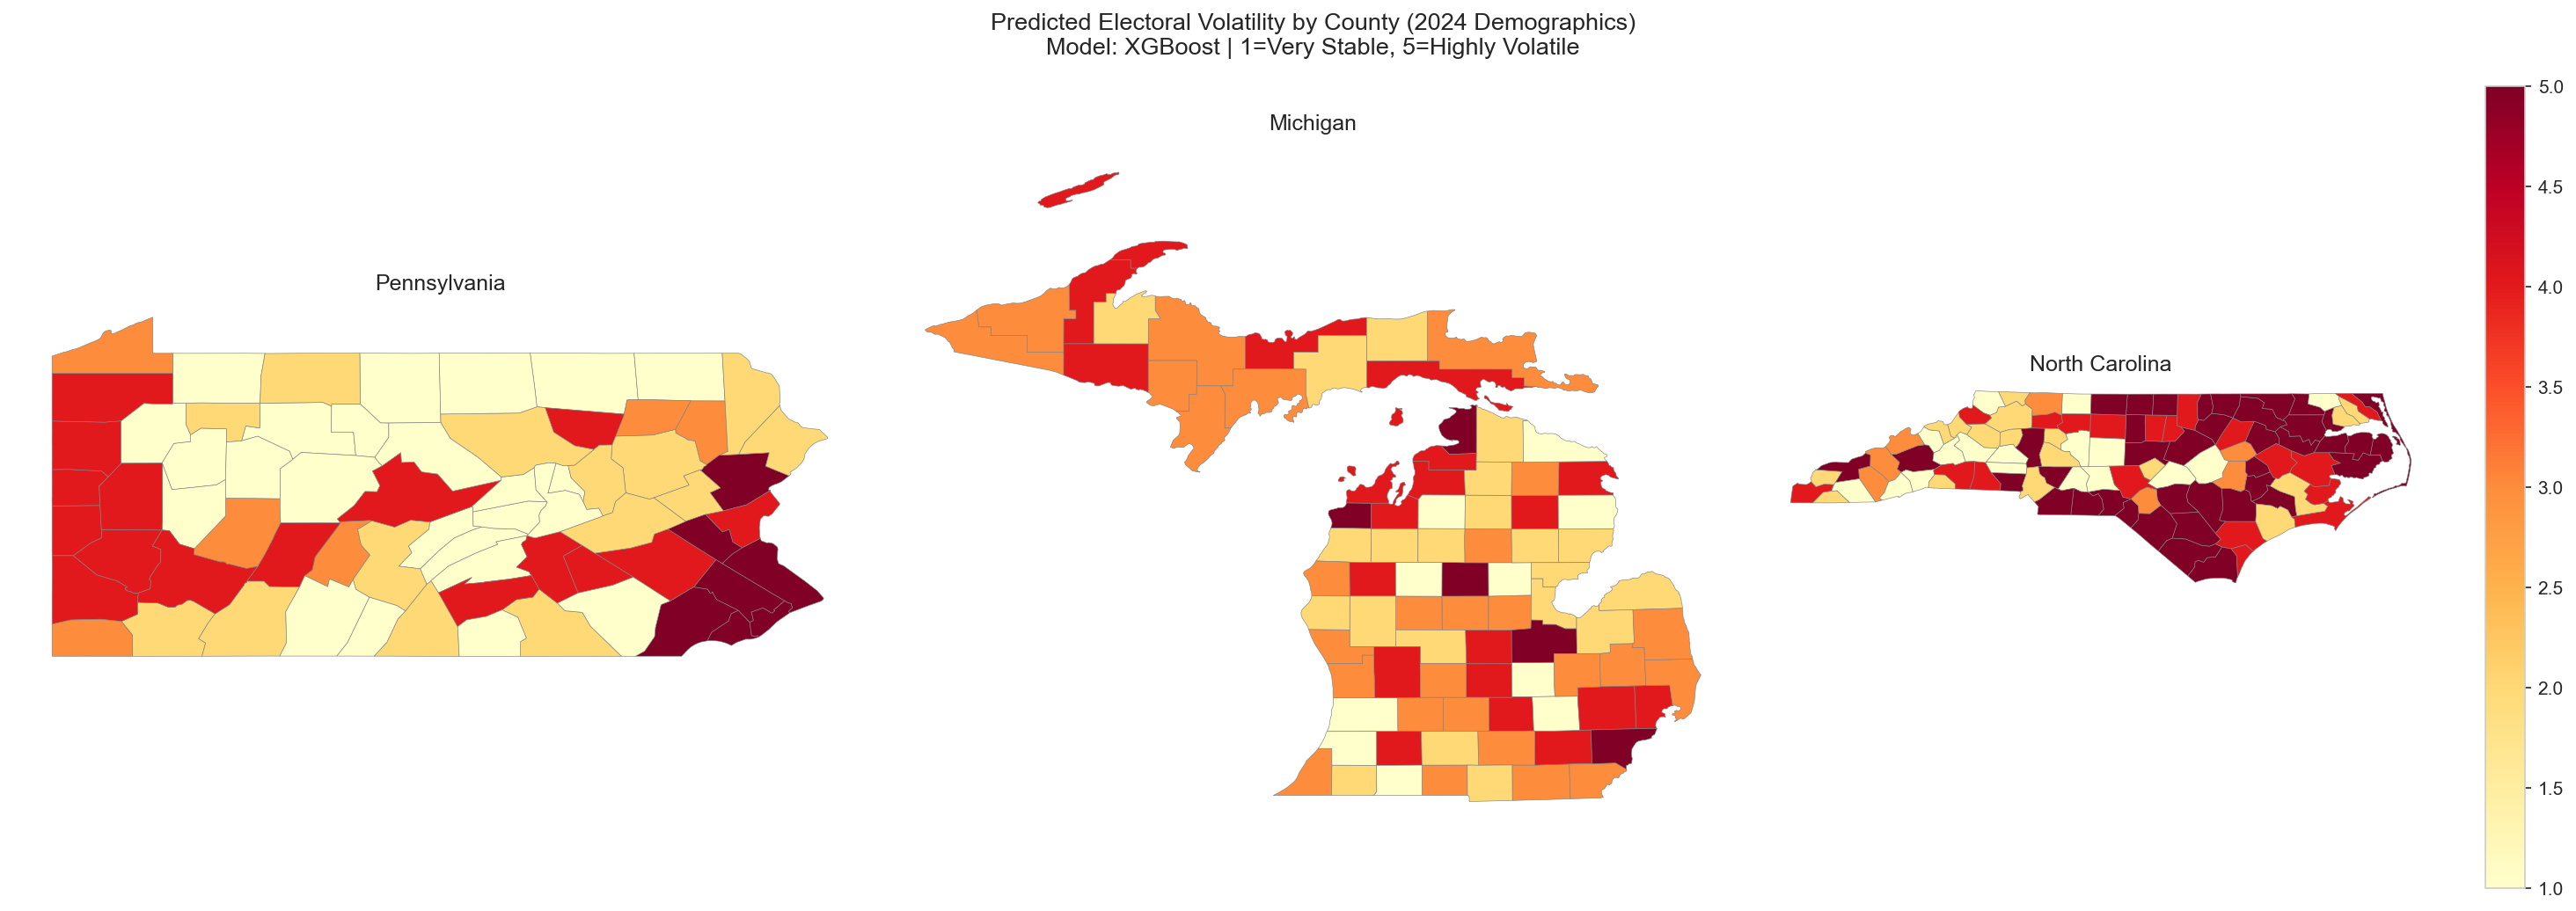

In [43]:
best_pred_col = 'rf_pred'
if 'XGBoost' in best_model_name:
    best_pred_col = 'xgb_pred'
elif 'SVM' in best_model_name:
    best_pred_col = 'svm_pred'

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
state_order = [('PA', '42', 'Pennsylvania'), ('MI', '26', 'Michigan'), ('NC', '37', 'North Carolina')]

for i, (abbr, prefix, full_name) in enumerate(state_order):
    state_data = geo_merged[geo_merged['county_fips'].str[:2] == prefix]
    state_data.plot(
        column=best_pred_col, ax=axes[i], legend=(i == 2),
        cmap='YlOrRd', vmin=1, vmax=5,
        edgecolor='gray', linewidth=0.3,
        missing_kwds={'color': 'lightgray', 'edgecolor': 'gray', 'linewidth': 0.3}
    )
    axes[i].set_title(full_name, fontsize=12)
    axes[i].set_axis_off()

plt.suptitle(f'Predicted Electoral Volatility by County (2024 Demographics)\n'
             f'Model: {best_model_name} | 1=Very Stable, 5=Highly Volatile',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/choropleth_volatility_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Map 2 — Demographic Misfit Score by County

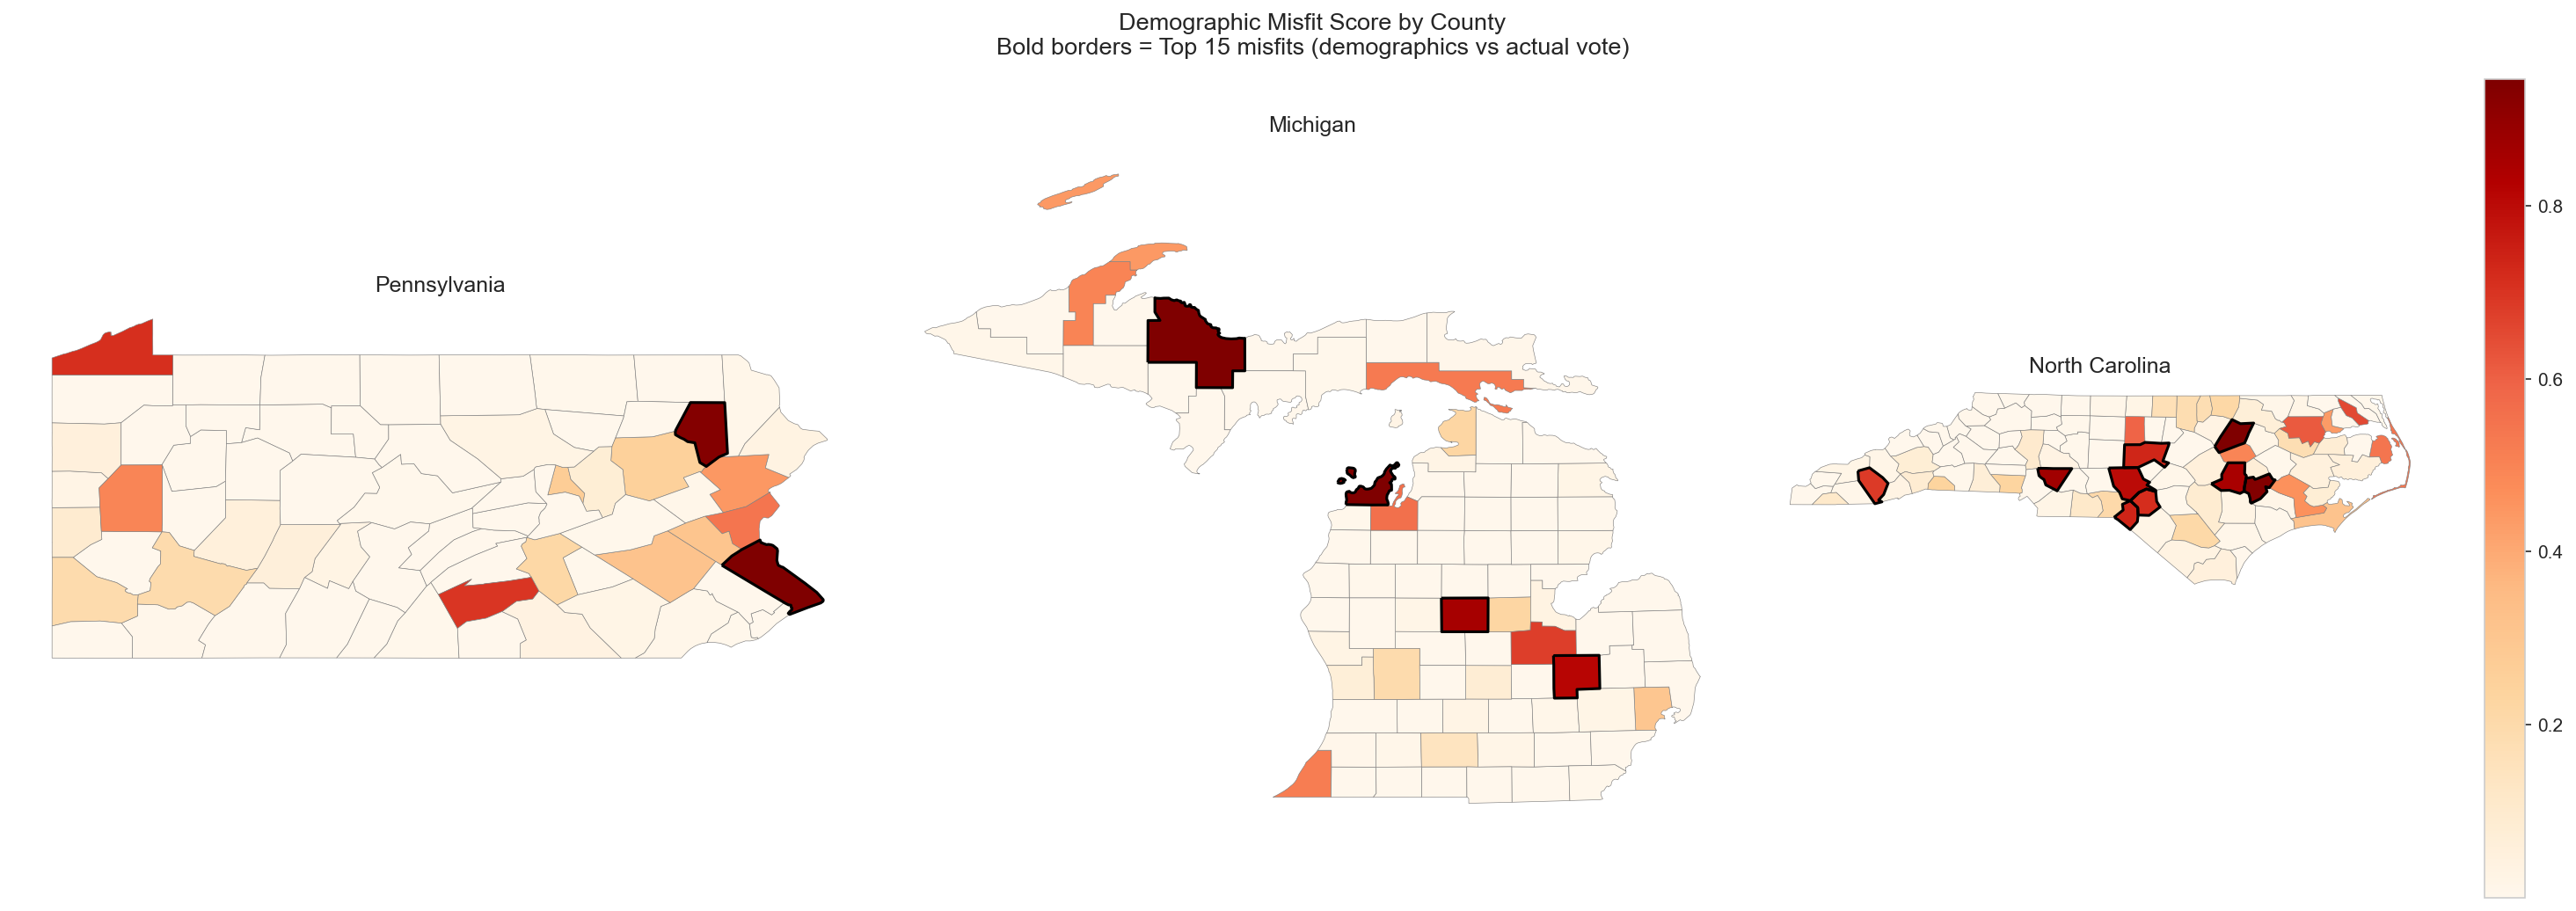

In [44]:
top15_fips = set(misfits['county_fips'].values)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (abbr, prefix, full_name) in enumerate(state_order):
    state_data = misfit_merged[misfit_merged['county_fips'].str[:2] == prefix]
    state_data.plot(
        column='misfit_score', ax=axes[i], legend=(i == 2),
        cmap='OrRd', edgecolor='gray', linewidth=0.3,
        missing_kwds={'color': 'lightgray', 'edgecolor': 'gray', 'linewidth': 0.3}
    )

    top15_state = state_data[state_data['county_fips'].isin(top15_fips)]
    if len(top15_state) > 0:
        top15_state.boundary.plot(ax=axes[i], edgecolor='black', linewidth=1.5)

    axes[i].set_title(full_name, fontsize=12)
    axes[i].set_axis_off()

plt.suptitle('Demographic Misfit Score by County\n'
             'Bold borders = Top 15 misfits (demographics vs actual vote)',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/choropleth_misfit_score.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Sam Handoff — Clustering Comparison

The following files are ready for Sam's k-means clustering comparison.

In [45]:
print('=' * 60)
print('HANDOFF TO SAM — Clustering Comparison')
print('=' * 60)
print(f'\nFiles produced:')
print(f'  1. {BASE}/classification_dataset_250.csv')
print(f'     - 250 counties, {len(feature_names)} scaled demographic features + targets')
print(f'     - Features: {feature_names}')
print(f'  2. {BASE}/classification_predictions.csv')
print(f'     - All model predictions + misfit scores')
print(f'\nFor clustering comparison:')
print(f'  - Run k-means on the same {len(feature_names)} demographic features')
print(f'  - Use the scaled features in classification_dataset_250.csv')
print(f'  - Return CSV with columns: county_fips, kmeans_cluster_label')
print(f'  - Antoni will compute Adjusted Rand Index + cross-tabulation')
print(f'\nTarget variable: vol_quintile_num (1-5 quintiles of vol_z_abs_sum)')
print(f'Key question: do unsupervised clusters align with volatility quintiles?')

HANDOFF TO SAM — Clustering Comparison

Files produced:
  1. ../data/processed/classification_dataset_250.csv
     - 250 counties, 28 scaled demographic features + targets
     - Features: ['median_age', 'pct_black', 'pct_asian', 'pct_two_or_more_races', 'pct_hispanic', 'pct_hs_or_higher', 'pct_bachelors_plus', 'pct_below_poverty', 'pct_income_under_25k', 'pct_income_50k_100k', 'unemployment_rate', 'pct_owner_occupied', 'pct_drive_alone', 'pct_carpool', 'pct_public_transit', 'pct_work_from_home', 'pct_family_households', 'pct_married_couple', 'pct_living_alone', 'pct_senior_65plus', 'pct_young_adult_18_24', 'pct_foreign_born', 'race_entropy_norm', 'log_total_population', 'log_population_density', 'log_median_household_income', 'log_median_home_value', 'log_median_gross_rent']
  2. ../data/processed/classification_predictions.csv
     - All model predictions + misfit scores

For clustering comparison:
  - Run k-means on the same 28 demographic features
  - Use the scaled features in cla